# Baseline model: predicting temporal AIT activity from static DINOv3 features

## Main idea

This notebook predicts the complete temporal AIT population response to a static image using a frozen DINOv3 representation and a small trainable temporal decoder. The model does not receive a video or any other temporal input. Instead, it learns a sequence of temporal queries that extracts a different mixture of either whole DINO layers or individual embedding features at each neural-response time point.

The central hypothesis is therefore:

> Does selecting individual DINO embedding features, rather than mixing layers only as wholes, improve prediction of temporal AIT population responses?

The complete pipeline is:

```text
Static image
    |
    +-- Frozen DINOv3 ViT-L, or cached DINOv3 activations
    |
    v
Four layer representations [B, 4, 1024]
    |
    +-- layer mode: project four whole layer vectors
    +-- feature mode: expose 4 x 1024 embedding coordinates
    |
Learned temporal queries [30, 128]
    |
    v
Attention at each time point
    +-- layer weights   [B, 30, 4]
    +-- feature weights [B, 30, 4, 1024]
    |
    v
Time-indexed latent representation [B, 30, 128]
    |
    v
Temporal MLP and neural prediction MLP
    |
    v
Predicted AIT activity [B, 30 time bins, 25 neurons]
```

## Executed configuration

The saved execution uses monkey `three0`, session `250313`, area `AIT`, and stimulus set `talia_20each_tizi`. Neural activity is taken from `natraster` between 0 and 300 ms and resampled from 1000 Hz to 100 Hz, producing 30 ten-millisecond bins. The resulting data contain 776 stimuli and 25 AIT channels.

The visual backbone is DINOv3 ViT-L/16 at an input resolution of 224 x 224 pixels. Mean-pooled representations are taken from layers 3, 13, 16, and 20. Each selected layer contributes a 1024-dimensional vector. The current run uses cached activations with shape `[776, 4, 1024]`; raw-image input is also supported.

Training uses a batch size of 64, a 20% validation fraction, 400 epochs, AdamW with learning rate `1e-3` and weight decay `1e-4`, and dropout `0.5`. The temporal embedding and value dimensions are both 128, while the hidden dimension of the two decoder MLPs is 32. `attention_granularity` selects `"layer"` or `"feature"`; the current configuration uses feature-level attention.

## 1. Neural-data loading and alignment

The neural loaders return activity with shape `[neurons, time, samples]`. Two source formats are supported:

- `natraster`, used in the saved run, contains unique-image averaged responses. It loads the requested temporal window, converts the data to `float32`, selects the requested brain-area channels, resamples the signal, and aligns its stimulus dimension to the `ImageFolder` ordering. The executed result has shape `[25, 30, 776]`.
- `raster` contains repeated single trials. It loads neural data in chunks, reads the filename associated with each trial, and maps every occurrence to the corresponding source image. Repeated presentations remain separate neural samples.

Stimulus alignment is an essential part of the pipeline. `neural_image_indices` maps every neural sample to the correct row of the image dataset or cached activation array. The notebook checks that the number of mappings agrees with the neural sample dimension and that every mapped index is valid.

## 2. Visual inputs and frozen DINO features

Images are indexed through `torchvision.datasets.ImageFolder`. `ProcessorTransform` applies the preprocessing recipe saved with the Hugging Face checkpoint, and the notebook verifies that the processor returns the configured 224 x 224 spatial resolution. Class labels created by `ImageFolder` are not used.

There are two input modes:

- With `training_input_mode="activations"`, the loader returns precomputed features with shape `[layers, embedding] = [4, 1024]`. This is the efficient default because the backbone is frozen.
- With `training_input_mode="images"`, the loader returns a processed image with shape `[3, 224, 224]`. DINO is then run online under `torch.no_grad()`, and forward hooks collect the selected layer outputs.

In both modes, DINO is used only as a fixed feature extractor. All its parameters have `requires_grad=False`, and the model overrides `train()` so that the backbone remains in evaluation mode while the decoder is trained.

## 3. Dataset and DataLoaders

`NeuralInputDataset` joins each visual input to its neural target. It transposes neural activity from `[neurons, time, samples]` to `[samples, time, neurons]`. A sample therefore contains either cached features `[4, 1024]` or an image `[3, 224, 224]`, together with a target `[30, 25]`.

The class performs early checks for invalid modes, missing cached activations, incorrect tensor dimensions, mismatches between neural trials and image mappings, and indices outside the source image dataset.

The train/validation split is made over unique image identities rather than directly over trials. This is important in `raster` mode: every repeated presentation of one image is kept in the same partition, preventing image leakage. The executed split contains 621 training images and 155 validation images. Training batches are shuffled; validation batches are not.

## 4. Model architecture

### Frozen encoder

The encoder is a 24-block DINOv3 ViT-L with embedding dimension 1024. Only four intermediate layer representations are retained. The trainable network operates on these representations rather than modifying the backbone.

### Layer-level and feature-level attention inputs

The model supports two attention granularities. `attention_granularity="layer"` preserves the original architecture: each 1024-dimensional layer vector is projected into one key and one value of dimension 128:

```text
layer features X: [B, 4, 1024]
keys K:           [B, 4, 128]
values V:         [B, 4, 128]
```

With `attention_granularity="feature"`, the attention axis instead contains all `4 * 1024 = 4096` individual embedding coordinates. Every layer-feature coordinate has its own learned 128-dimensional key direction. Its DINO activation modulates that key, making feature selection stimulus-dependent. Attention gates the normalized feature vector, which is then projected from 4096 coordinates into the 128-dimensional value space. These are embedding/channel features from the mean-pooled layer output, not spatial patch tokens.

### Learned temporal queries and configurable attention

The network learns one query for every coarse neural time point. With 30 target bins and a temporal compression ratio of one, there are 30 queries of dimension 128. Queries are shared across images, but their attention weights are stimulus-dependent because the keys are computed from the current image.

In layer mode, scaled dot-product attention is computed over the four DINO layers:

$$A_{btl} = \operatorname{softmax}_l\left(\frac{Q_t K_{bl}^{T}}{\sqrt{d_k}}\right).$$

In feature mode, the same query scores every layer-feature coordinate and the softmax is taken jointly over all 4096 coordinates:

$$A_{btle} = \operatorname{softmax}_{l,e}\left(\frac{Q_t K_{ble}^{T}}{\sqrt{d_k}}\right).$$

The resulting feature weights have shape `[B, 30, 4, 1024]`. They multiplicatively gate the corresponding DINO coordinates before projection into one latent vector per time bin. Neither mode attends over time, so this added selectivity does not introduce cross-temporal interaction.

### Pointwise temporal features and neural prediction

The temporal feature MLP is `Linear(128, 32) -> GELU -> Dropout -> Linear(32, 128)`. It acts only on the final feature dimension and therefore processes every time bin independently. The compression ratio is required to equal one, so every temporal query corresponds to exactly one neural time bin.

A shared pointwise feature MLP, `Linear(128, 32) -> GELU -> Dropout`, processes each time-indexed latent without mixing time points. It is followed by 30 separate `Linear(32, 25)` readout heads, one for each target bin. Head `t` sees only latent `t`, and its weights receive loss gradients only from neural target `t`. The final output has shape `[B, 30, 25]`. Excluding DINO, layer mode has approximately 304,000 trainable parameters and feature mode approximately 1.09 million.

## 5. Meaning of temporal modelling in this baseline

The model is temporal in its output parameterization, but it is neither recurrent nor autoregressive. All 30 time points are predicted simultaneously. There is no RNN, GRU, LSTM, temporal self-attention, or state passed from one time point to the next.

Temporal structure is generated mainly by the sequence of learned queries: different time points can select different mixtures of whole DINO layers or individual embedding coordinates. The feature transformations are applied pointwise, and the final neural readout weights are specific to each time bin. The compression ratio is required to be one, so time points do not communicate directly. This model therefore tests time-dependent feature selection and time-specific neural mappings rather than temporal state evolution.

## 6. Loss function

The training objective first computes a separate mean-squared error for every time bin:

$$\mathcal{L}_t = \frac{1}{BN}\sum_{b,n}(\hat{y}_{btn}-y_{btn})^2, \qquad \mathcal{L}=\frac{1}{T}\sum_t\mathcal{L}_t.$$

Prediction bin `t` is compared only with neural target bin `t`; the loss contains no shifted, adjacent-bin, or all-pairs temporal terms. The scalar used for backpropagation is the equal average of the 30 time-bin losses. There is no per-neuron normalization, time-dependent weighting, Poisson likelihood, correlation loss, noise-ceiling correction, attention regularization, or temporal-smoothness penalty. Responses with larger variance can therefore have a larger effect on the optimization.

## 7. Optimization and training loop

AdamW receives only parameters for which `requires_grad=True`: temporal embeddings, layer projections or feature keys/value projection, normalization parameters, decoder MLPs, and an optional query projection. DINO parameters are excluded.

During one training epoch, the notebook:

1. Sets the decoder to training mode while keeping DINO in evaluation mode.
2. Moves inputs and neural targets to the selected device.
3. Runs the forward pass and computes the aligned loss separately for every time bin.
4. Backpropagates the loss.
5. Applies one AdamW update.
6. Clears gradients with `zero_grad(set_to_none=True)`.
7. Accumulates the batch loss weighted by its number of samples.

The gradient reset occurs after each optimizer step, with an initial reset before training. This is valid, although resetting immediately before the forward pass is the more common convention. There is no learning-rate scheduler, gradient clipping, mixed-precision training, early stopping, or model checkpointing.

## 8. Validation and diagnostics

The randomly initialized decoder is evaluated before the first update. After every training epoch, the complete validation set is evaluated with the model in evaluation mode and gradient tracking disabled. A fixed validation example is plotted every ten epochs; prediction and target are averaged across neurons to leave one temporal trajectory. This plot is intuitive but can hide channel-specific errors.

After training, attention weights are collected for all validation images. Layer mode is plotted directly. In feature mode, weights are averaged across the 1024 coordinates of each target layer and renormalized over layers; this is equivalent to plotting each layer's total attention mass and keeps the heatmap comparable with layer mode. The result shows whether early and late neural predictions rely on different DINO depths, while raw `[image, time, layer, feature]` weights remain available for finer analysis.

## 9. Ridge-regression reference

The notebook also fits a simpler linear reference. The four DINO vectors are concatenated into 4096 input features, while the complete neural response is flattened into 750 outputs (`30 time bins * 25 neurons`). Ridge regression is fitted on the same image-grouped training split and evaluated on the same validation split.

The imported implementation uses `RidgeCV` over ten candidate alphas from `1e-6` to `1e3`. The later notebook description calls this a fixed-alpha ridge model, but the implementation actually performs alpha selection on the training data.

## 10. Results in the saved execution

The saved outputs below were produced by the preceding shared-readout version and must be regenerated after introducing the time-bin-specific heads. In that preceding run, the randomly initialized model started at validation MSE `0.065310`; ridge obtained `0.045250`; and the neural model reached approximately `0.044928` around epoch 33. These numbers are retained only as a historical reference and are not results for the time-local architecture.

The feature-attention architecture must be rerun before it can be compared with layer attention or ridge. For a fair comparison, run both attention granularities with the same image split and random initialization seed. The notebook still does not retain the best validation checkpoint, so the final model need not be the best model encountered during training.

## 11. Strengths and current limitations

Important strengths are explicit alignment checks, image-grouped data splitting, efficient cached-feature training, careful freezing of DINO, configurable layer/feature attention, and comparison against a strong linear reference. The same model can use cached activations during training and raw images during inference.

The main limitations are:

- There is one train/validation split and no independent test set or cross-validation.
- NumPy controls the split seed, but PyTorch initialization, dropout, and DataLoader shuffling are not fully seeded.
- There is no early stopping or best-model checkpoint.
- Aggregate MSE is not complemented by per-neuron correlation, R-squared, explained variance, or noise-ceiling-normalized scores.
- There is no temporal smoothness or biologically motivated latency constraint.
- With compression ratio one, there is no explicit interaction between time points.
- The model can reveal changing layer preferences, but cannot establish whether recurrent state evolution is required to explain AIT dynamics.

This makes the notebook a useful, interpretable baseline for later comparisons with recurrent, state-space, or temporally interacting models.

In [1]:
import os
import sys
from dataclasses import dataclass, field
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import yaml
import torch
from torch.utils.data import DataLoader, Subset
from torchvision.datasets import ImageFolder
from transformers import AutoImageProcessor

# Locate the repository whether Jupyter starts in the project root or scripts folder.
cwd = Path.cwd().resolve()
candidate_roots = [cwd, *cwd.parents]
PROJECT_ROOT = next(
    (path for path in candidate_roots if (path / "config.yaml").is_file()),
    None,
)
if PROJECT_ROOT is None:
    raise FileNotFoundError("Could not locate config.yaml from the current directory.")
# end if PROJECT_ROOT is None

ENV = os.getenv("MY_ENV", "tiziano_mac_mini")
with open(PROJECT_ROOT / "config.yaml", "r") as f:
    config = yaml.safe_load(f)
paths = config[ENV]["paths"]

# Put this repository first so another project's package cannot shadow it.
project_src_path = str((PROJECT_ROOT / "python_scripts" / "src").resolve())
useful_stuff_path = str(Path(paths["useful_stuff_path"]).resolve())
for source_path in (useful_stuff_path, project_src_path):
    while source_path in sys.path:
        sys.path.remove(source_path)
    # end while source path is already registered
    sys.path.insert(0, source_path)
# end for source path

# Reimport the development loader even if an older copy is kernel-cached.
sys.modules.pop("project_specific_utils.dataloader", None)
sys.modules.pop("project_specific_utils", None)
import project_specific_utils.dataloader as neural_dataloader
expected_dataloader_path = (
    Path(project_src_path) / "project_specific_utils" / "dataloader.py"
).resolve()
loaded_dataloader_path = Path(neural_dataloader.__file__).resolve()
if loaded_dataloader_path != expected_dataloader_path:
    raise ImportError(
        f"Expected neural loader {expected_dataloader_path}, loaded "
        f"{loaded_dataloader_path}."
    )
# end if a different project's loader was imported

# from II_analyses.static_encoding import (
#     compute_static_prediction_II,
#     fit_static_projection,
# )
from project_specific_utils.dataloader import (
    load_img_natraster,
    load_img_raster,
    make_neural_input_loader,
    map_image_order_from_ann_to_monkey,
    map_trial_image_order_to_ann,
)
from IT_recap.hf_feature_extraction import (
    ProcessorTransform,
    is_valid_image_file,
    load_hf_layer_features,
)
from IT_recap.neural_prediction_training import (
    aggregate_attention_by_layer,
    collect_concatenated_layer_regression_data,
    neural_activity_timebin_mse_loss,
    plot_mean_channel_reconstruction,
    test_step,
    training_step,
)
from model_classes.temporal_models import BaselineModel
from useful_stuff.general_utils.regression import linear_encoding
from useful_stuff.image_processing.computational_models import imgANN


In [2]:
@dataclass
class Cfg:
    # Neural recording and image-set parameters.
    # Paul natraster example: source="natraster", monkey="paul",
    # date="230204", folder="fewer_occlusion".
    neural_data_source: str = "natraster"  # "raster" or "natraster"
    monkey_name: str = "three0"
    date: str = "250313"
    brain_area: str = "AIT"
    folder_name: str = "talia_20each_tizi"
    raster_file: str = "rasters_three0_250313to21.mat" # None #"paul_nat" #
    raster_key: str = "rasters"
    raster_image_names_file: str = "allimages_three0_250313to21.mat"
    raster_image_names_key: str = "allimages"
    original_fs: int = 1000
    new_fs: int = 100
    time_start_ms: float = 0
    time_end_ms: float = 300.0
    raster_chunk_size: int = 512
    # pca_comp = 100
    # Static model-feature parameters.
    model_name: str = "dino_v3_l"
    model_source: str = "facebook/dinov3-vitl16-pretrain-lvd1689m"
    img_size: int = 224
    use_fast_processor: bool = True
    pkg = "hf"
    layer_names: list[str] = field(default_factory=lambda: [
        "layer.3.mlp.down_proj",
        "layer.13.mlp.down_proj",
        "layer.16.mlp.down_proj",
        "layer.20.mlp.down_proj",
    ])
    pooling: str = "mean"
    trust_remote_code = True
    attn_implementation = "sdpa"
    # Use "images" if cached DINO features do not exist for folder_name.
    training_input_mode: str = "activations"  #"images" # "images" or "activations"

    batch_size = 64
    validation_fraction: float = 0.2
    random_seed: int = 0
    epochs: int = 5000
    learning_rate: float = 1e-3
    weight_decay: float = 1e-4
    temporal_embedding_dim: int = 128
    value_dim: int = 128
    temporal_compression_ratio: int = 1
    # "layer" attends over four layer vectors; "feature" attends over
    # every embedding coordinate within each selected layer.
    attention_granularity: str = "feature"
    mlp_hidden_dim: int = 32
    dropout: float = 0.3
    reconstruction_plot_interval: int = 100
    reconstruction_sample_index: int = 10
    
# EOC


cfg = Cfg()
cfg

Cfg(neural_data_source='natraster', monkey_name='three0', date='250313', brain_area='AIT', folder_name='talia_20each_tizi', raster_file='rasters_three0_250313to21.mat', raster_key='rasters', raster_image_names_file='allimages_three0_250313to21.mat', raster_image_names_key='allimages', original_fs=1000, new_fs=100, time_start_ms=0, time_end_ms=300.0, raster_chunk_size=512, model_name='dino_v3_l', model_source='facebook/dinov3-vitl16-pretrain-lvd1689m', img_size=224, use_fast_processor=True, layer_names=['layer.3.mlp.down_proj', 'layer.13.mlp.down_proj', 'layer.16.mlp.down_proj', 'layer.20.mlp.down_proj'], pooling='mean', training_input_mode='activations', validation_fraction=0.2, random_seed=0, epochs=5000, learning_rate=0.001, weight_decay=0.0001, temporal_embedding_dim=128, value_dim=128, temporal_compression_ratio=1, attention_granularity='feature', mlp_hidden_dim=32, dropout=0.3, reconstruction_plot_interval=100, reconstruction_sample_index=10)

## Load and align the static spaces

The neural data are shaped `(neurons, timepoints, samples)`. With `neural_data_source="raster"`, samples are repeated single trials and their explicit presentation names determine the image mapping. With `neural_data_source="natraster"`, samples are unique-image averages and the ordering follows `run_static_dRSA.py`: `load_img_natraster` plus `map_image_order_from_ann_to_monkey`. Cached DINO features remain in ImageFolder source order.

In [3]:
# Load the preprocessing recipe saved with the Hugging Face checkpoint.
image_processor = AutoImageProcessor.from_pretrained(
    cfg.model_source,
    use_fast=cfg.use_fast_processor,
)

dataset_path = Path(paths["livingstone_lab"]) / "Stimuli" / cfg.folder_name
dataset = ImageFolder(
    root=dataset_path,
    transform=ProcessorTransform(image_processor),
    is_valid_file=is_valid_image_file,
    allow_empty=True,
)

# Fail early if the checkpoint processor and configured model size disagree.
sample_image, _ = dataset[0]
sample_shape = tuple(sample_image.shape[-2:])
if sample_shape != (cfg.img_size, cfg.img_size):
    raise ValueError(
        f"Processor returned {sample_shape}, expected "
        f"{(cfg.img_size, cfg.img_size)}."
    )
# end if processor output size differs from model input size

# Align neural samples to ImageFolder following the appropriate source format.
if cfg.neural_data_source == "raster":
    raster, neural_image_names = load_img_raster(
        paths=paths,
        monkey_name=cfg.monkey_name,
        raster_file=cfg.raster_file,
        image_names_file=cfg.raster_image_names_file,
        raster_key=cfg.raster_key,
        image_names_key=cfg.raster_image_names_key,
        original_fs=cfg.original_fs,
        new_fs=cfg.new_fs,
        time_start_ms=cfg.time_start_ms,
        time_end_ms=cfg.time_end_ms,
        brain_area=cfg.brain_area,
        chunk_size=cfg.raster_chunk_size,
    )
    neural_image_indices = map_trial_image_order_to_ann(
        neural_image_names,
        dataset,
    )
elif cfg.neural_data_source == "natraster":
    # Match run_static_dRSA.py: natraster rows follow sorted unique names.
    raster = load_img_natraster(
        paths=paths,
        monkey_name=cfg.monkey_name,
        date=cfg.date,
        original_fs=cfg.original_fs,
        new_fs=cfg.new_fs,
        time_start_ms=cfg.time_start_ms,
        time_end_ms=cfg.time_end_ms,
        brain_area=cfg.brain_area,
    )
    neural_image_indices = np.asarray(
        map_image_order_from_ann_to_monkey(
            paths,
            cfg.monkey_name,
            cfg.date,
            dataset,
        ),
        dtype=int,
    )
else:
    raise ValueError(
        "neural_data_source must be either 'raster' or 'natraster'."
    )
# end if repeated raster or averaged natraster is requested

raster_array = raster.get_array()

if raster_array.ndim != 3:
    raise ValueError(
        "Expected neural data with shape (neurons, timepoints, trials), "
        f"received {raster_array.shape}."
    )
# end if raster_array.ndim != 3

if len(neural_image_indices) != raster_array.shape[2]:
    raise ValueError(
        f"Found {len(neural_image_indices)} aligned images but "
        f"{raster_array.shape[2]} neural samples."
    )
# end if neural data and image ordering differ

# Cached DINO outputs are needed only when bypassing the frozen backbone.
precomputed_layer_features = None
if cfg.training_input_mode == "activations":
    precomputed_layer_features = load_hf_layer_features(
        output_dir=Path(paths["data_path"]) / "models",
        dataset_name=cfg.folder_name,
        model_name=cfg.model_name,
        img_size=cfg.img_size,
        layer_names=cfg.layer_names,
        pooling=cfg.pooling,
    )
    if precomputed_layer_features.shape[0] != len(dataset):
        raise ValueError(
            "Cached features and ImageFolder have different image counts: "
            f"{precomputed_layer_features.shape[0]} and {len(dataset)}."
        )
    # end if cached features and ImageFolder are misaligned
elif cfg.training_input_mode != "images":
    raise ValueError(
        "training_input_mode must be either 'images' or 'activations'."
    )
# end if cached features are requested

print(f"{cfg.neural_data_source} neural data: {raster_array.shape}")
print(f"Aligned unique stimuli: {len(np.unique(neural_image_indices))}")
if precomputed_layer_features is not None:
    print(f"Cached DINO features: {precomputed_layer_features.shape}")
else:
    print("Training input: images (DINO runs online)")
# end if cached features were loaded


natraster neural data: (25, 30, 776)
Aligned unique stimuli: 776
Cached DINO features: (776, 4, 1024)


In [4]:
# NeuralInputDataset is implemented in project_specific_utils.dataloader.


In [5]:
ann = imgANN(
    model_name=cfg.model_name,
    pkg=cfg.pkg,
    img_size=cfg.img_size,
    pooling=cfg.pooling,
    dtype=torch.float32,
    attn_implementation=cfg.attn_implementation,
    repo_url=cfg.model_source,
    trust_remote_code=cfg.trust_remote_code,
)

17:45:06 - device being used: mps


In [6]:
# Change cfg.training_input_mode to switch the training input source.
loader = make_neural_input_loader(
    input_mode=cfg.training_input_mode,
    image_dataset=dataset,
    activations=precomputed_layer_features,
    neural_activity=raster_array,
    image_indices=neural_image_indices,
    batch_size=cfg.batch_size,
    shuffle=True,
    pin_memory=torch.device(ann.get_device()).type == "cuda",
)


In [7]:
# BaselineModel is implemented in model_classes.temporal_models.


## Time-bin-specific neural-activity prediction loss

The loss is computed separately at each time bin. Prediction bin $t$ is compared only with neural target bin $t$:

$$\mathcal{L}_t = \frac{1}{BN} \sum_{b,n} (\hat{y}_{btn} - y_{btn})^2.$$

The scalar training objective is the equal average of those independent time-bin losses:

$$\mathcal{L} = \frac{1}{T} \sum_t \mathcal{L}_t.$$

There are no comparisons between different time bins and no temporal shifting or temporal averaging before the error is computed.

In [8]:
# neural_activity_timebin_mse_loss is implemented in IT_recap.neural_prediction_training.


# Training and online validation
## training (repeat for the whole training set -> 1 epoch)
1. Pass minibatch
2. compute loss
3. backpropagate
4. do the optimizer step
5. zero the gradient
6. accumulate the sample-weighted training loss

## testing (repeat for the whole validation set at every epoch)
1. switch the network to evaluation mode
2. compute the loss
3. accumulate the sample-weighted validation loss


In [9]:
# Training, validation, plotting, and ridge-data helpers are implemented in IT_recap.neural_prediction_training.


In [10]:
# Reuse the same initialization seed when comparing attention modes.
torch.manual_seed(cfg.random_seed)
m = BaselineModel(
    ann,
    layers=cfg.layer_names,
    temporal_embedding_dim=cfg.temporal_embedding_dim,
    value_dim=cfg.value_dim,
    n_timepoints=raster_array.shape[1],
    temporal_compression_ratio=cfg.temporal_compression_ratio,
    n_neurons=raster_array.shape[0],
    mlp_hidden_dim=cfg.mlp_hidden_dim,
    dropout=cfg.dropout,
    attention_granularity=cfg.attention_granularity,
).to(ann.get_device())
m

BaselineModel(
  (encoder_backbone): DINOv3ViTModel(
    (embeddings): DINOv3ViTEmbeddings(
      (patch_embeddings): Conv2d(3, 1024, kernel_size=(16, 16), stride=(16, 16))
    )
    (rope_embeddings): DINOv3ViTRopePositionEmbedding()
    (layer): ModuleList(
      (0-23): 24 x DINOv3ViTLayer(
        (norm1): LayerNorm((1024,), eps=1e-05, elementwise_affine=True, bias=True)
        (attention): DINOv3ViTAttention(
          (k_proj): Linear(in_features=1024, out_features=1024, bias=False)
          (v_proj): Linear(in_features=1024, out_features=1024, bias=True)
          (q_proj): Linear(in_features=1024, out_features=1024, bias=True)
          (o_proj): Linear(in_features=1024, out_features=1024, bias=True)
        )
        (layer_scale1): DINOv3ViTLayerScale()
        (drop_path): Identity()
        (norm2): LayerNorm((1024,), eps=1e-05, elementwise_affine=True, bias=True)
        (mlp): DINOv3ViTMLP(
          (up_proj): Linear(in_features=1024, out_features=4096, bias=True)
    

split: 621 images / 621 trials for training; 155 images / 155 trials for validation
concatenated-layer ridge | validation 0.045250
epoch 000/5000 | validation 0.064556


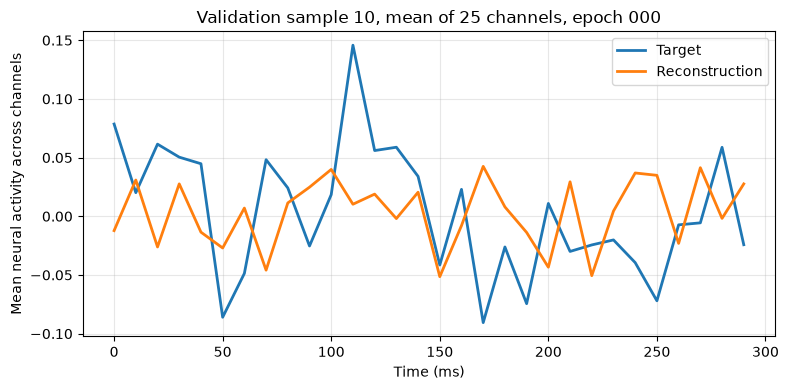

epoch 001/5000 | train 0.063220 | validation 0.059632
epoch 002/5000 | train 0.059147 | validation 0.055808
epoch 003/5000 | train 0.055586 | validation 0.052078
epoch 004/5000 | train 0.052414 | validation 0.049448
epoch 005/5000 | train 0.050404 | validation 0.048132
epoch 006/5000 | train 0.049282 | validation 0.047519
epoch 007/5000 | train 0.048680 | validation 0.047219
epoch 008/5000 | train 0.048243 | validation 0.047051
epoch 009/5000 | train 0.048000 | validation 0.046915
epoch 010/5000 | train 0.047813 | validation 0.046780
epoch 011/5000 | train 0.047613 | validation 0.046695
epoch 012/5000 | train 0.047463 | validation 0.046724
epoch 013/5000 | train 0.047321 | validation 0.046463
epoch 014/5000 | train 0.047172 | validation 0.046389
epoch 015/5000 | train 0.047069 | validation 0.046323
epoch 016/5000 | train 0.046938 | validation 0.046223
epoch 017/5000 | train 0.046824 | validation 0.046127
epoch 018/5000 | train 0.046784 | validation 0.046090
epoch 019/5000 | train 0.046

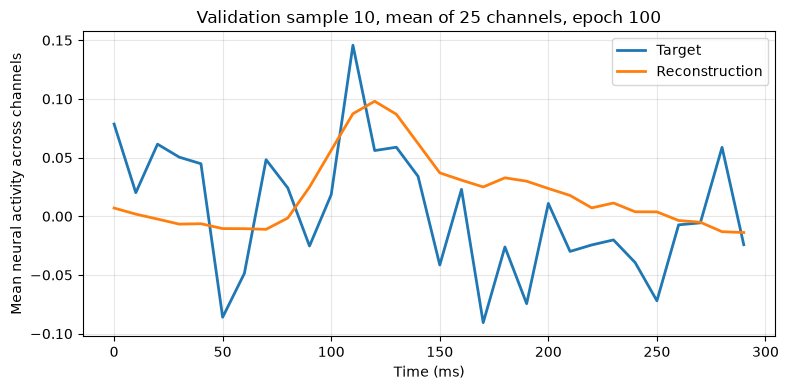

epoch 101/5000 | train 0.043977 | validation 0.044808
epoch 102/5000 | train 0.043970 | validation 0.044828
epoch 103/5000 | train 0.043947 | validation 0.044767
epoch 104/5000 | train 0.043936 | validation 0.044777
epoch 105/5000 | train 0.043926 | validation 0.044757
epoch 106/5000 | train 0.043900 | validation 0.044743
epoch 107/5000 | train 0.043884 | validation 0.044743
epoch 108/5000 | train 0.043917 | validation 0.044723
epoch 109/5000 | train 0.043920 | validation 0.044722
epoch 110/5000 | train 0.043980 | validation 0.044750
epoch 111/5000 | train 0.044040 | validation 0.044807
epoch 112/5000 | train 0.043992 | validation 0.044720
epoch 113/5000 | train 0.043935 | validation 0.044713
epoch 114/5000 | train 0.043879 | validation 0.044729
epoch 115/5000 | train 0.043851 | validation 0.044788
epoch 116/5000 | train 0.043863 | validation 0.044796
epoch 117/5000 | train 0.043809 | validation 0.044737
epoch 118/5000 | train 0.043823 | validation 0.044957
epoch 119/5000 | train 0.043

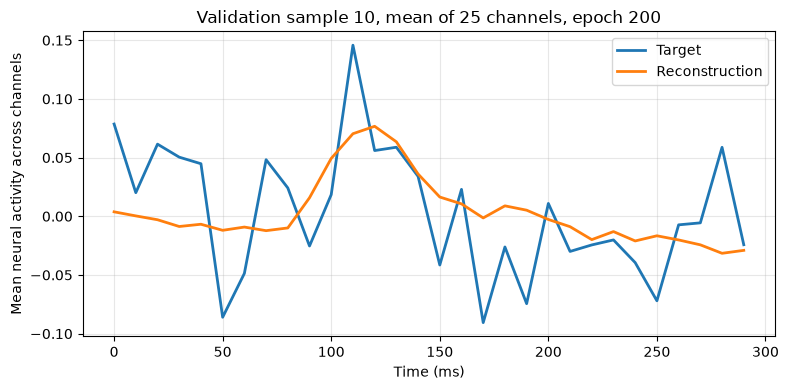

epoch 201/5000 | train 0.042986 | validation 0.044685
epoch 202/5000 | train 0.042977 | validation 0.044616
epoch 203/5000 | train 0.042914 | validation 0.044612
epoch 204/5000 | train 0.042867 | validation 0.044596
epoch 205/5000 | train 0.042870 | validation 0.044616
epoch 206/5000 | train 0.042856 | validation 0.044628
epoch 207/5000 | train 0.042898 | validation 0.044610
epoch 208/5000 | train 0.042871 | validation 0.044645
epoch 209/5000 | train 0.042854 | validation 0.044633
epoch 210/5000 | train 0.042851 | validation 0.044730
epoch 211/5000 | train 0.042849 | validation 0.044641
epoch 212/5000 | train 0.042821 | validation 0.044655
epoch 213/5000 | train 0.042780 | validation 0.044656
epoch 214/5000 | train 0.042784 | validation 0.044653
epoch 215/5000 | train 0.042751 | validation 0.044660
epoch 216/5000 | train 0.042793 | validation 0.044716
epoch 217/5000 | train 0.042846 | validation 0.044624
epoch 218/5000 | train 0.042826 | validation 0.044633
epoch 219/5000 | train 0.042

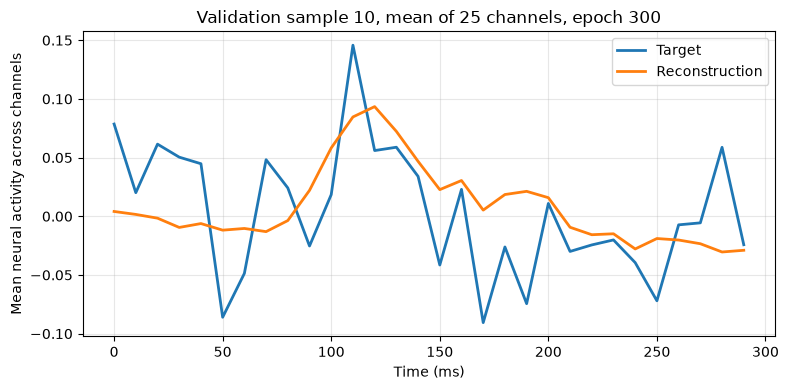

epoch 301/5000 | train 0.042200 | validation 0.044956
epoch 302/5000 | train 0.042172 | validation 0.044933
epoch 303/5000 | train 0.042145 | validation 0.044999
epoch 304/5000 | train 0.042127 | validation 0.044953
epoch 305/5000 | train 0.042138 | validation 0.044954
epoch 306/5000 | train 0.042137 | validation 0.044953
epoch 307/5000 | train 0.042105 | validation 0.045000
epoch 308/5000 | train 0.042076 | validation 0.044927
epoch 309/5000 | train 0.042050 | validation 0.044979
epoch 310/5000 | train 0.042042 | validation 0.044978
epoch 311/5000 | train 0.042001 | validation 0.044976
epoch 312/5000 | train 0.042059 | validation 0.045149
epoch 313/5000 | train 0.042165 | validation 0.045052
epoch 314/5000 | train 0.042046 | validation 0.045009
epoch 315/5000 | train 0.042006 | validation 0.045022
epoch 316/5000 | train 0.042022 | validation 0.044985
epoch 317/5000 | train 0.041990 | validation 0.045006
epoch 318/5000 | train 0.042019 | validation 0.044997
epoch 319/5000 | train 0.041

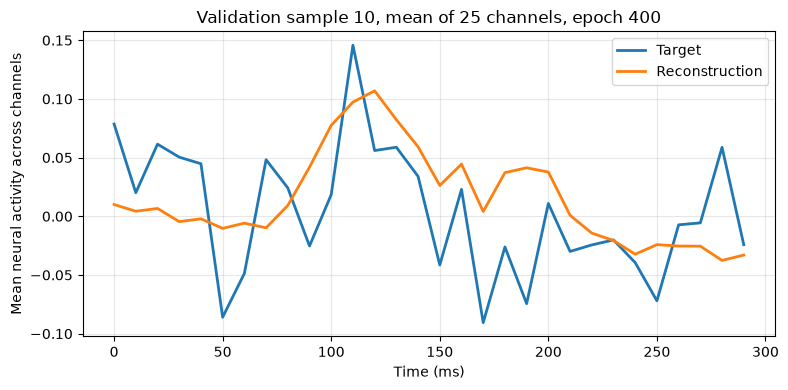

epoch 401/5000 | train 0.041529 | validation 0.045579
epoch 402/5000 | train 0.041482 | validation 0.045516
epoch 403/5000 | train 0.041416 | validation 0.045447
epoch 404/5000 | train 0.041427 | validation 0.045585
epoch 405/5000 | train 0.041498 | validation 0.045725
epoch 406/5000 | train 0.041396 | validation 0.045641
epoch 407/5000 | train 0.041406 | validation 0.045810
epoch 408/5000 | train 0.041451 | validation 0.045866
epoch 409/5000 | train 0.041410 | validation 0.046001
epoch 410/5000 | train 0.041372 | validation 0.045756
epoch 411/5000 | train 0.041405 | validation 0.046078
epoch 412/5000 | train 0.041441 | validation 0.045485
epoch 413/5000 | train 0.041374 | validation 0.045600
epoch 414/5000 | train 0.041399 | validation 0.045818
epoch 415/5000 | train 0.041430 | validation 0.045514
epoch 416/5000 | train 0.041392 | validation 0.045626
epoch 417/5000 | train 0.041357 | validation 0.045686
epoch 418/5000 | train 0.041317 | validation 0.045634
epoch 419/5000 | train 0.041

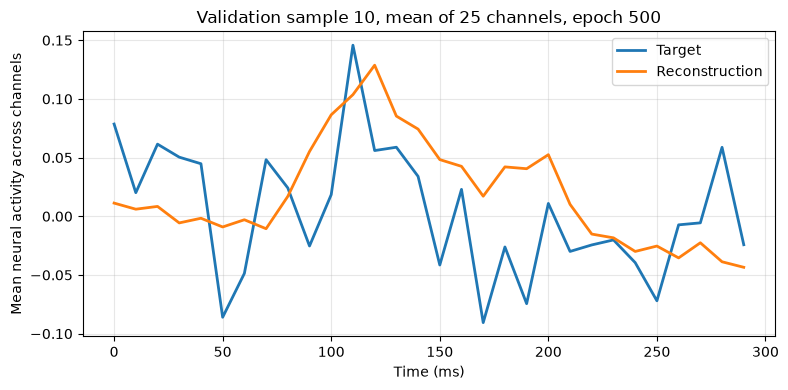

epoch 501/5000 | train 0.041812 | validation 0.045508
epoch 502/5000 | train 0.041619 | validation 0.045615
epoch 503/5000 | train 0.041485 | validation 0.045974
epoch 504/5000 | train 0.041326 | validation 0.046475
epoch 505/5000 | train 0.041238 | validation 0.046394
epoch 506/5000 | train 0.041138 | validation 0.046584
epoch 507/5000 | train 0.041105 | validation 0.046328
epoch 508/5000 | train 0.041087 | validation 0.046317
epoch 509/5000 | train 0.041011 | validation 0.046688
epoch 510/5000 | train 0.041003 | validation 0.047348
epoch 511/5000 | train 0.041047 | validation 0.048043
epoch 512/5000 | train 0.040994 | validation 0.048722
epoch 513/5000 | train 0.041243 | validation 0.046565
epoch 514/5000 | train 0.041136 | validation 0.047874
epoch 515/5000 | train 0.040991 | validation 0.046752
epoch 516/5000 | train 0.040998 | validation 0.049246
epoch 517/5000 | train 0.041008 | validation 0.048102
epoch 518/5000 | train 0.041059 | validation 0.048735
epoch 519/5000 | train 0.041

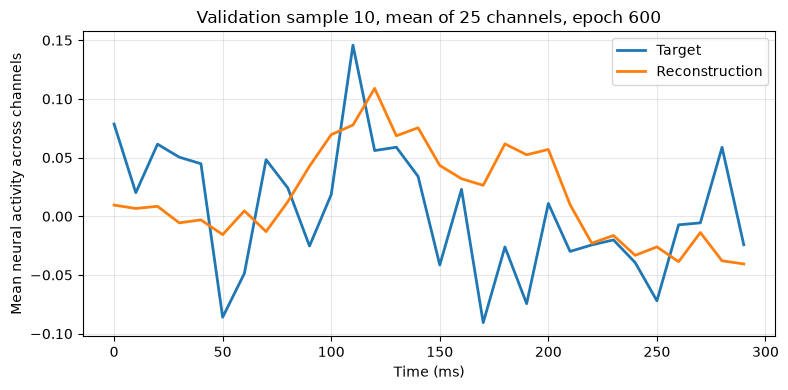

epoch 601/5000 | train 0.040357 | validation 0.046626
epoch 602/5000 | train 0.040251 | validation 0.046391
epoch 603/5000 | train 0.040232 | validation 0.046346
epoch 604/5000 | train 0.040254 | validation 0.046980
epoch 605/5000 | train 0.040238 | validation 0.048002
epoch 606/5000 | train 0.040175 | validation 0.047058
epoch 607/5000 | train 0.040227 | validation 0.047826
epoch 608/5000 | train 0.040180 | validation 0.048477
epoch 609/5000 | train 0.040157 | validation 0.047019
epoch 610/5000 | train 0.040174 | validation 0.046330
epoch 611/5000 | train 0.040186 | validation 0.046123
epoch 612/5000 | train 0.040184 | validation 0.045929
epoch 613/5000 | train 0.040352 | validation 0.046218
epoch 614/5000 | train 0.040277 | validation 0.046157
epoch 615/5000 | train 0.040249 | validation 0.046002
epoch 616/5000 | train 0.040287 | validation 0.046164
epoch 617/5000 | train 0.040211 | validation 0.046365
epoch 618/5000 | train 0.040281 | validation 0.046025
epoch 619/5000 | train 0.040

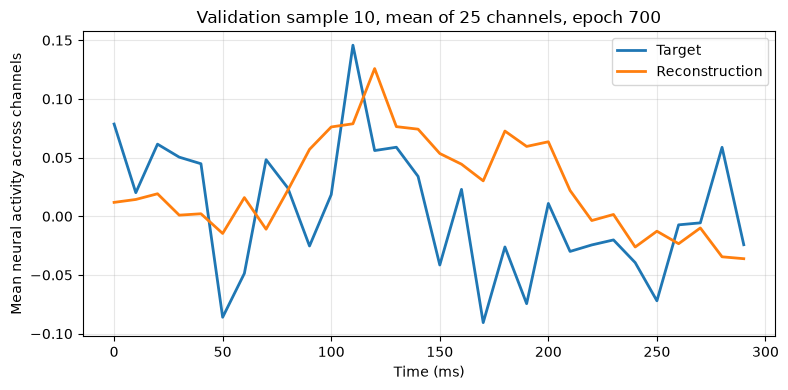

epoch 701/5000 | train 0.039948 | validation 0.046346
epoch 702/5000 | train 0.039915 | validation 0.046258
epoch 703/5000 | train 0.039924 | validation 0.046428
epoch 704/5000 | train 0.039974 | validation 0.046201
epoch 705/5000 | train 0.039961 | validation 0.046377
epoch 706/5000 | train 0.039925 | validation 0.046278
epoch 707/5000 | train 0.039921 | validation 0.046278
epoch 708/5000 | train 0.039903 | validation 0.046496
epoch 709/5000 | train 0.039938 | validation 0.046379
epoch 710/5000 | train 0.039964 | validation 0.046331
epoch 711/5000 | train 0.039991 | validation 0.046304
epoch 712/5000 | train 0.039950 | validation 0.046257
epoch 713/5000 | train 0.039888 | validation 0.046274
epoch 714/5000 | train 0.039925 | validation 0.046488
epoch 715/5000 | train 0.039886 | validation 0.046283
epoch 716/5000 | train 0.039819 | validation 0.046378
epoch 717/5000 | train 0.039818 | validation 0.046233
epoch 718/5000 | train 0.039830 | validation 0.046332
epoch 719/5000 | train 0.039

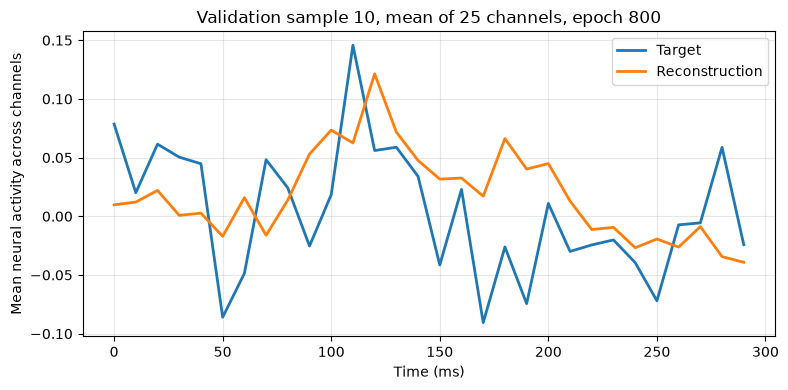

epoch 801/5000 | train 0.039832 | validation 0.046610
epoch 802/5000 | train 0.039674 | validation 0.046469
epoch 803/5000 | train 0.039626 | validation 0.046402
epoch 804/5000 | train 0.039620 | validation 0.046640
epoch 805/5000 | train 0.039546 | validation 0.046589
epoch 806/5000 | train 0.039559 | validation 0.046396
epoch 807/5000 | train 0.039669 | validation 0.046491
epoch 808/5000 | train 0.039673 | validation 0.046416
epoch 809/5000 | train 0.040051 | validation 0.046242
epoch 810/5000 | train 0.040155 | validation 0.046301
epoch 811/5000 | train 0.039953 | validation 0.046368
epoch 812/5000 | train 0.039783 | validation 0.046293
epoch 813/5000 | train 0.039730 | validation 0.046509
epoch 814/5000 | train 0.039656 | validation 0.046405
epoch 815/5000 | train 0.039562 | validation 0.046500
epoch 816/5000 | train 0.039518 | validation 0.046608
epoch 817/5000 | train 0.039460 | validation 0.046703
epoch 818/5000 | train 0.039494 | validation 0.046509
epoch 819/5000 | train 0.039

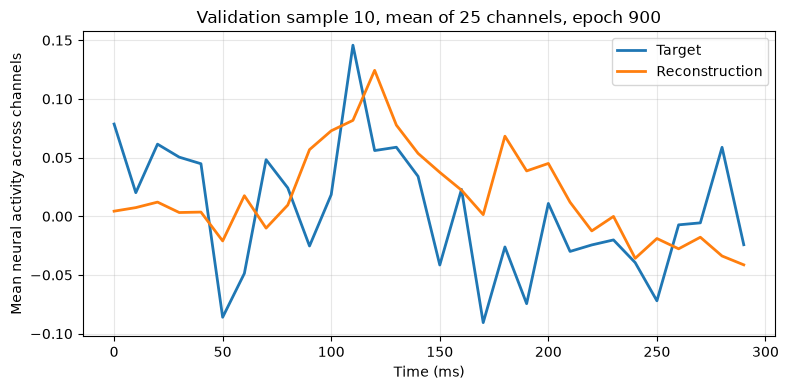

epoch 901/5000 | train 0.039401 | validation 0.047258
epoch 902/5000 | train 0.039367 | validation 0.046506
epoch 903/5000 | train 0.039345 | validation 0.046855
epoch 904/5000 | train 0.039329 | validation 0.046851
epoch 905/5000 | train 0.039275 | validation 0.046711
epoch 906/5000 | train 0.039203 | validation 0.046734
epoch 907/5000 | train 0.039159 | validation 0.046872
epoch 908/5000 | train 0.039211 | validation 0.046899
epoch 909/5000 | train 0.039225 | validation 0.046810
epoch 910/5000 | train 0.039157 | validation 0.046931
epoch 911/5000 | train 0.039315 | validation 0.047012
epoch 912/5000 | train 0.039375 | validation 0.046556
epoch 913/5000 | train 0.039282 | validation 0.047010
epoch 914/5000 | train 0.039228 | validation 0.047022
epoch 915/5000 | train 0.039144 | validation 0.046879
epoch 916/5000 | train 0.039204 | validation 0.047111
epoch 917/5000 | train 0.039141 | validation 0.047510
epoch 918/5000 | train 0.039079 | validation 0.047502
epoch 919/5000 | train 0.039

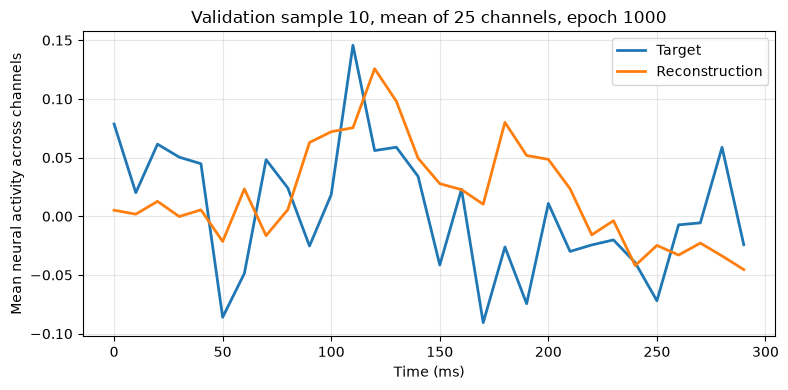

epoch 1001/5000 | train 0.038943 | validation 0.047173
epoch 1002/5000 | train 0.038838 | validation 0.047030
epoch 1003/5000 | train 0.038906 | validation 0.047201
epoch 1004/5000 | train 0.038836 | validation 0.047211
epoch 1005/5000 | train 0.038882 | validation 0.047251
epoch 1006/5000 | train 0.039021 | validation 0.047166
epoch 1007/5000 | train 0.039176 | validation 0.046971
epoch 1008/5000 | train 0.039098 | validation 0.047315
epoch 1009/5000 | train 0.038977 | validation 0.047145
epoch 1010/5000 | train 0.038965 | validation 0.047200
epoch 1011/5000 | train 0.038911 | validation 0.047033
epoch 1012/5000 | train 0.038925 | validation 0.046838
epoch 1013/5000 | train 0.039094 | validation 0.047025
epoch 1014/5000 | train 0.038970 | validation 0.046942
epoch 1015/5000 | train 0.038963 | validation 0.047242
epoch 1016/5000 | train 0.038945 | validation 0.047107
epoch 1017/5000 | train 0.038780 | validation 0.046888
epoch 1018/5000 | train 0.038874 | validation 0.047091
epoch 1019

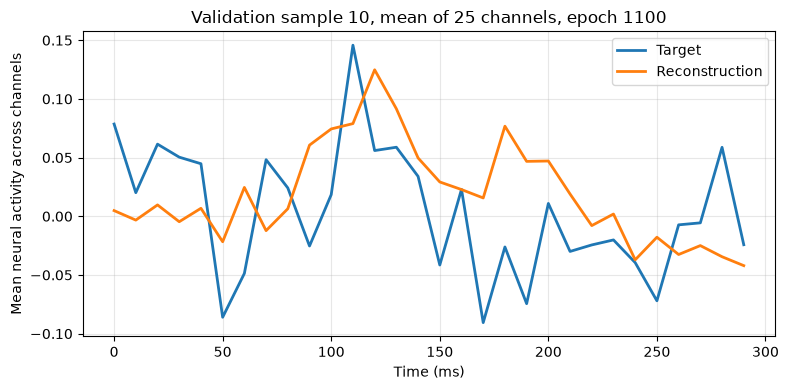

epoch 1101/5000 | train 0.039081 | validation 0.047155
epoch 1102/5000 | train 0.039116 | validation 0.047072
epoch 1103/5000 | train 0.038915 | validation 0.047298
epoch 1104/5000 | train 0.038760 | validation 0.047200
epoch 1105/5000 | train 0.038700 | validation 0.047257
epoch 1106/5000 | train 0.038637 | validation 0.047360
epoch 1107/5000 | train 0.038719 | validation 0.047111
epoch 1108/5000 | train 0.038624 | validation 0.047273
epoch 1109/5000 | train 0.038770 | validation 0.046999
epoch 1110/5000 | train 0.039092 | validation 0.046950
epoch 1111/5000 | train 0.039024 | validation 0.047298
epoch 1112/5000 | train 0.038876 | validation 0.047262
epoch 1113/5000 | train 0.038783 | validation 0.047174
epoch 1114/5000 | train 0.038795 | validation 0.047124
epoch 1115/5000 | train 0.038734 | validation 0.047153
epoch 1116/5000 | train 0.038712 | validation 0.047187
epoch 1117/5000 | train 0.038665 | validation 0.047306
epoch 1118/5000 | train 0.038636 | validation 0.047089
epoch 1119

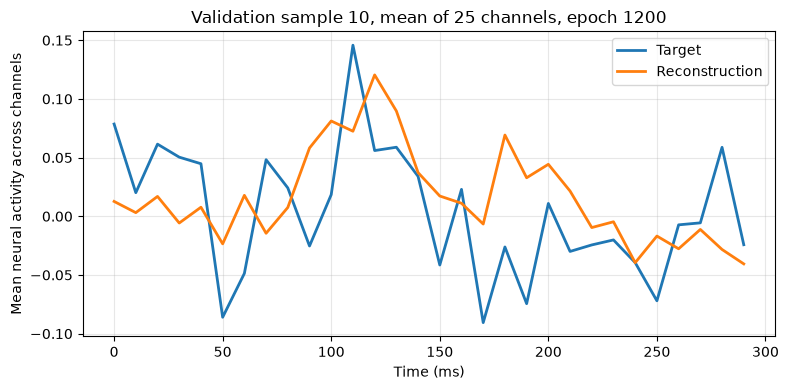

epoch 1201/5000 | train 0.038501 | validation 0.047407
epoch 1202/5000 | train 0.038457 | validation 0.047428
epoch 1203/5000 | train 0.038397 | validation 0.047584
epoch 1204/5000 | train 0.038424 | validation 0.047373
epoch 1205/5000 | train 0.038506 | validation 0.047433
epoch 1206/5000 | train 0.038492 | validation 0.047587
epoch 1207/5000 | train 0.038478 | validation 0.047672
epoch 1208/5000 | train 0.038572 | validation 0.047540
epoch 1209/5000 | train 0.038528 | validation 0.047740
epoch 1210/5000 | train 0.038466 | validation 0.047771
epoch 1211/5000 | train 0.038407 | validation 0.047708
epoch 1212/5000 | train 0.038736 | validation 0.047396
epoch 1213/5000 | train 0.038750 | validation 0.047193
epoch 1214/5000 | train 0.038658 | validation 0.047744
epoch 1215/5000 | train 0.038638 | validation 0.047309
epoch 1216/5000 | train 0.038621 | validation 0.047459
epoch 1217/5000 | train 0.038488 | validation 0.047613
epoch 1218/5000 | train 0.038544 | validation 0.048058
epoch 1219

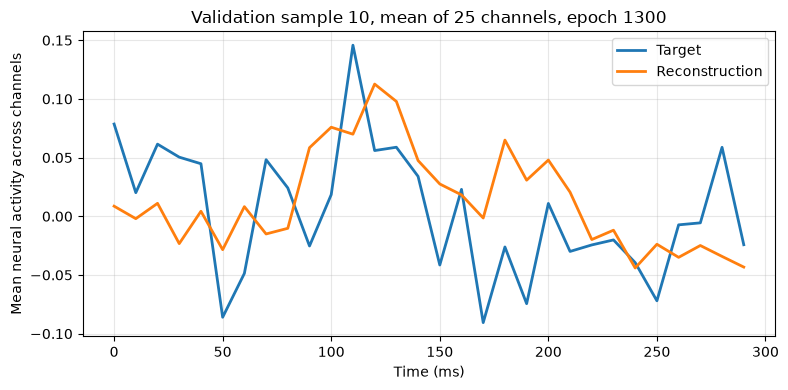

epoch 1301/5000 | train 0.038310 | validation 0.047476
epoch 1302/5000 | train 0.038274 | validation 0.047339
epoch 1303/5000 | train 0.038256 | validation 0.047446
epoch 1304/5000 | train 0.038264 | validation 0.047531
epoch 1305/5000 | train 0.038426 | validation 0.047196
epoch 1306/5000 | train 0.039172 | validation 0.046923
epoch 1307/5000 | train 0.039173 | validation 0.047008
epoch 1308/5000 | train 0.038948 | validation 0.047254
epoch 1309/5000 | train 0.038761 | validation 0.047244
epoch 1310/5000 | train 0.038609 | validation 0.047331
epoch 1311/5000 | train 0.038548 | validation 0.047451
epoch 1312/5000 | train 0.038474 | validation 0.047476
epoch 1313/5000 | train 0.038451 | validation 0.047535
epoch 1314/5000 | train 0.038476 | validation 0.047374
epoch 1315/5000 | train 0.038438 | validation 0.047292
epoch 1316/5000 | train 0.038588 | validation 0.047480
epoch 1317/5000 | train 0.038417 | validation 0.047633
epoch 1318/5000 | train 0.038356 | validation 0.047449
epoch 1319

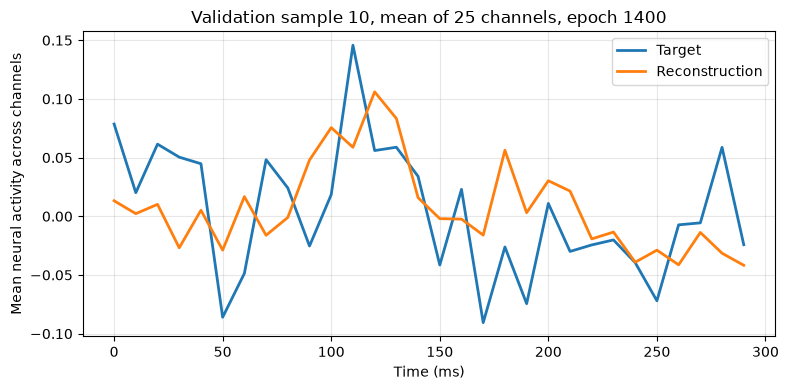

epoch 1401/5000 | train 0.038349 | validation 0.047472
epoch 1402/5000 | train 0.038262 | validation 0.047401
epoch 1403/5000 | train 0.038302 | validation 0.047574
epoch 1404/5000 | train 0.038243 | validation 0.047416
epoch 1405/5000 | train 0.038187 | validation 0.047678
epoch 1406/5000 | train 0.038185 | validation 0.047578
epoch 1407/5000 | train 0.038269 | validation 0.047367
epoch 1408/5000 | train 0.038265 | validation 0.047517
epoch 1409/5000 | train 0.038412 | validation 0.047282
epoch 1410/5000 | train 0.038449 | validation 0.047487
epoch 1411/5000 | train 0.038301 | validation 0.047325
epoch 1412/5000 | train 0.038294 | validation 0.047607
epoch 1413/5000 | train 0.038221 | validation 0.047461
epoch 1414/5000 | train 0.038193 | validation 0.047515
epoch 1415/5000 | train 0.038189 | validation 0.047772
epoch 1416/5000 | train 0.038103 | validation 0.047697
epoch 1417/5000 | train 0.038127 | validation 0.047694
epoch 1418/5000 | train 0.038075 | validation 0.047679
epoch 1419

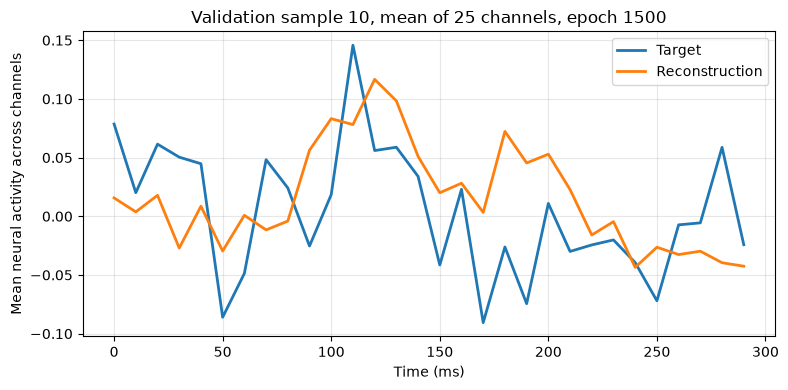

epoch 1501/5000 | train 0.038083 | validation 0.047702
epoch 1502/5000 | train 0.038051 | validation 0.047983
epoch 1503/5000 | train 0.037950 | validation 0.047935
epoch 1504/5000 | train 0.037947 | validation 0.047928
epoch 1505/5000 | train 0.037885 | validation 0.048052
epoch 1506/5000 | train 0.037990 | validation 0.047969
epoch 1507/5000 | train 0.037866 | validation 0.047945
epoch 1508/5000 | train 0.037936 | validation 0.048163
epoch 1509/5000 | train 0.037938 | validation 0.047970
epoch 1510/5000 | train 0.037900 | validation 0.047982
epoch 1511/5000 | train 0.037827 | validation 0.048015
epoch 1512/5000 | train 0.037875 | validation 0.047715
epoch 1513/5000 | train 0.038023 | validation 0.047839
epoch 1514/5000 | train 0.038204 | validation 0.047586
epoch 1515/5000 | train 0.038269 | validation 0.047638
epoch 1516/5000 | train 0.038164 | validation 0.047731
epoch 1517/5000 | train 0.038025 | validation 0.047675
epoch 1518/5000 | train 0.038022 | validation 0.047933
epoch 1519

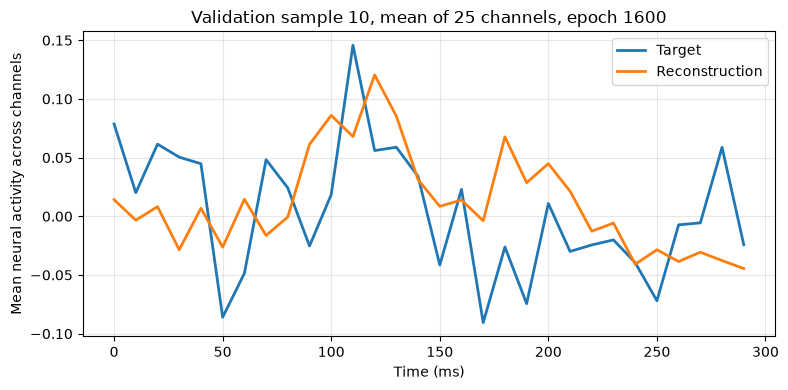

epoch 1601/5000 | train 0.038502 | validation 0.049016
epoch 1602/5000 | train 0.038262 | validation 0.049950
epoch 1603/5000 | train 0.038139 | validation 0.051105
epoch 1604/5000 | train 0.038047 | validation 0.051721
epoch 1605/5000 | train 0.037975 | validation 0.051114
epoch 1606/5000 | train 0.037981 | validation 0.049977
epoch 1607/5000 | train 0.037953 | validation 0.049718
epoch 1608/5000 | train 0.037918 | validation 0.050231
epoch 1609/5000 | train 0.037858 | validation 0.050005
epoch 1610/5000 | train 0.037877 | validation 0.049174
epoch 1611/5000 | train 0.038090 | validation 0.049052
epoch 1612/5000 | train 0.038084 | validation 0.049637
epoch 1613/5000 | train 0.037985 | validation 0.050251
epoch 1614/5000 | train 0.037892 | validation 0.050051
epoch 1615/5000 | train 0.037852 | validation 0.049883
epoch 1616/5000 | train 0.037902 | validation 0.049599
epoch 1617/5000 | train 0.037922 | validation 0.047984
epoch 1618/5000 | train 0.037957 | validation 0.047834
epoch 1619

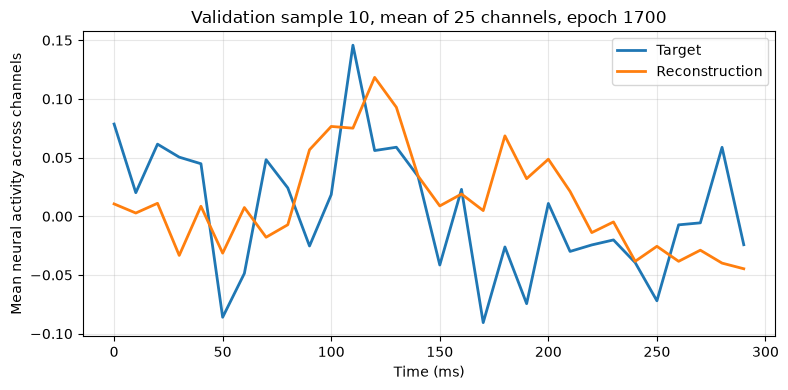

epoch 1701/5000 | train 0.037908 | validation 0.048457
epoch 1702/5000 | train 0.037776 | validation 0.048771
epoch 1703/5000 | train 0.037735 | validation 0.048819
epoch 1704/5000 | train 0.037660 | validation 0.048939
epoch 1705/5000 | train 0.037673 | validation 0.049114
epoch 1706/5000 | train 0.037676 | validation 0.049035
epoch 1707/5000 | train 0.037604 | validation 0.049148
epoch 1708/5000 | train 0.037614 | validation 0.048902
epoch 1709/5000 | train 0.037747 | validation 0.048630
epoch 1710/5000 | train 0.037782 | validation 0.048481
epoch 1711/5000 | train 0.037671 | validation 0.049057
epoch 1712/5000 | train 0.037979 | validation 0.048714
epoch 1713/5000 | train 0.038258 | validation 0.048516
epoch 1714/5000 | train 0.038555 | validation 0.049178
epoch 1715/5000 | train 0.038146 | validation 0.050523
epoch 1716/5000 | train 0.038030 | validation 0.050691
epoch 1717/5000 | train 0.038046 | validation 0.049971
epoch 1718/5000 | train 0.038044 | validation 0.049770
epoch 1719

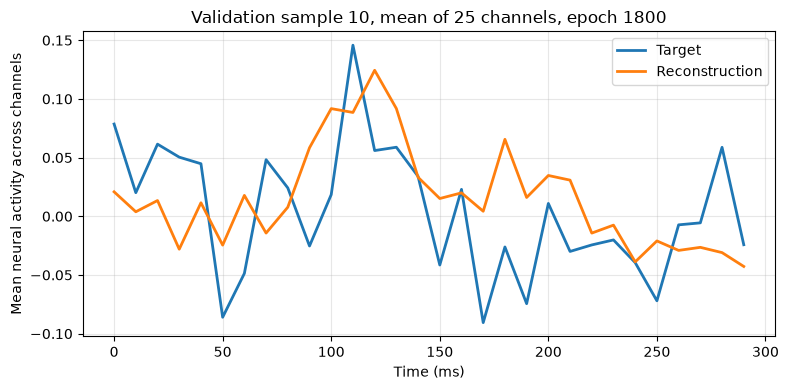

epoch 1801/5000 | train 0.038233 | validation 0.047569
epoch 1802/5000 | train 0.038204 | validation 0.047765
epoch 1803/5000 | train 0.037999 | validation 0.047788
epoch 1804/5000 | train 0.038074 | validation 0.047840
epoch 1805/5000 | train 0.038494 | validation 0.047712
epoch 1806/5000 | train 0.038501 | validation 0.047764
epoch 1807/5000 | train 0.038248 | validation 0.048114
epoch 1808/5000 | train 0.038080 | validation 0.048106
epoch 1809/5000 | train 0.037981 | validation 0.048302
epoch 1810/5000 | train 0.037980 | validation 0.048617
epoch 1811/5000 | train 0.038065 | validation 0.048412
epoch 1812/5000 | train 0.038437 | validation 0.047918
epoch 1813/5000 | train 0.038428 | validation 0.048093
epoch 1814/5000 | train 0.038292 | validation 0.048061
epoch 1815/5000 | train 0.038159 | validation 0.048283
epoch 1816/5000 | train 0.038047 | validation 0.048557
epoch 1817/5000 | train 0.037940 | validation 0.048466
epoch 1818/5000 | train 0.037855 | validation 0.048504
epoch 1819

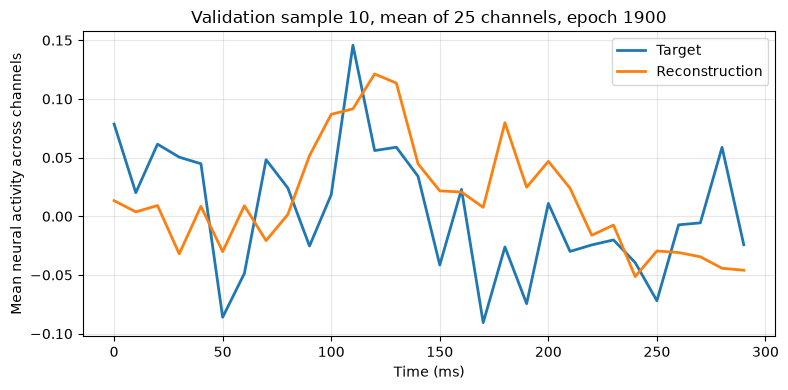

epoch 1901/5000 | train 0.038317 | validation 0.048382
epoch 1902/5000 | train 0.038285 | validation 0.048355
epoch 1903/5000 | train 0.038122 | validation 0.048431
epoch 1904/5000 | train 0.037869 | validation 0.048583
epoch 1905/5000 | train 0.037793 | validation 0.048850
epoch 1906/5000 | train 0.037677 | validation 0.049509
epoch 1907/5000 | train 0.037742 | validation 0.049136
epoch 1908/5000 | train 0.037593 | validation 0.049362
epoch 1909/5000 | train 0.037575 | validation 0.048952
epoch 1910/5000 | train 0.037527 | validation 0.049461
epoch 1911/5000 | train 0.037507 | validation 0.049377
epoch 1912/5000 | train 0.037485 | validation 0.049251
epoch 1913/5000 | train 0.037639 | validation 0.049238
epoch 1914/5000 | train 0.037572 | validation 0.049299
epoch 1915/5000 | train 0.037520 | validation 0.049530
epoch 1916/5000 | train 0.037559 | validation 0.048860
epoch 1917/5000 | train 0.037641 | validation 0.048920
epoch 1918/5000 | train 0.037579 | validation 0.049253
epoch 1919

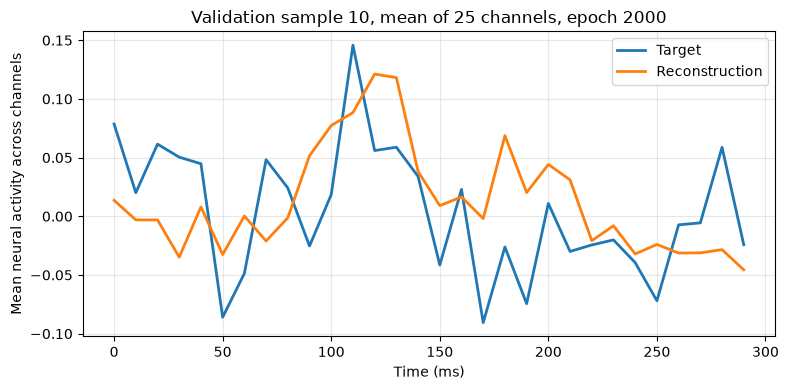

epoch 2001/5000 | train 0.037621 | validation 0.048150
epoch 2002/5000 | train 0.037575 | validation 0.048340
epoch 2003/5000 | train 0.037477 | validation 0.048382
epoch 2004/5000 | train 0.037426 | validation 0.048664
epoch 2005/5000 | train 0.037332 | validation 0.049178
epoch 2006/5000 | train 0.037309 | validation 0.049350
epoch 2007/5000 | train 0.037425 | validation 0.049608
epoch 2008/5000 | train 0.037444 | validation 0.049289
epoch 2009/5000 | train 0.037359 | validation 0.049046
epoch 2010/5000 | train 0.037290 | validation 0.048973
epoch 2011/5000 | train 0.037607 | validation 0.048776
epoch 2012/5000 | train 0.037441 | validation 0.049165
epoch 2013/5000 | train 0.037385 | validation 0.049074
epoch 2014/5000 | train 0.037339 | validation 0.048763
epoch 2015/5000 | train 0.037313 | validation 0.048699
epoch 2016/5000 | train 0.037493 | validation 0.048928
epoch 2017/5000 | train 0.037537 | validation 0.048357
epoch 2018/5000 | train 0.037382 | validation 0.048641
epoch 2019

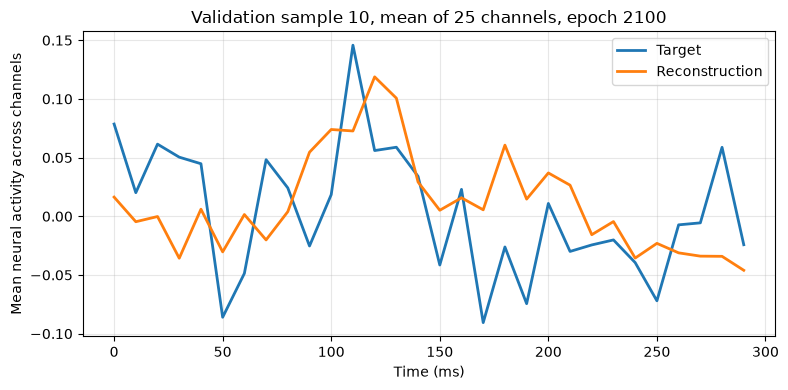

epoch 2101/5000 | train 0.037283 | validation 0.048349
epoch 2102/5000 | train 0.037181 | validation 0.048350
epoch 2103/5000 | train 0.037248 | validation 0.048345
epoch 2104/5000 | train 0.037237 | validation 0.047979
epoch 2105/5000 | train 0.037318 | validation 0.048062
epoch 2106/5000 | train 0.037353 | validation 0.048113
epoch 2107/5000 | train 0.037253 | validation 0.048313
epoch 2108/5000 | train 0.037235 | validation 0.048142
epoch 2109/5000 | train 0.037216 | validation 0.048199
epoch 2110/5000 | train 0.037175 | validation 0.048226
epoch 2111/5000 | train 0.037242 | validation 0.048297
epoch 2112/5000 | train 0.037307 | validation 0.048027
epoch 2113/5000 | train 0.037338 | validation 0.048450
epoch 2114/5000 | train 0.037297 | validation 0.048252
epoch 2115/5000 | train 0.037341 | validation 0.048317
epoch 2116/5000 | train 0.037476 | validation 0.048294
epoch 2117/5000 | train 0.037399 | validation 0.048480
epoch 2118/5000 | train 0.037243 | validation 0.048470
epoch 2119

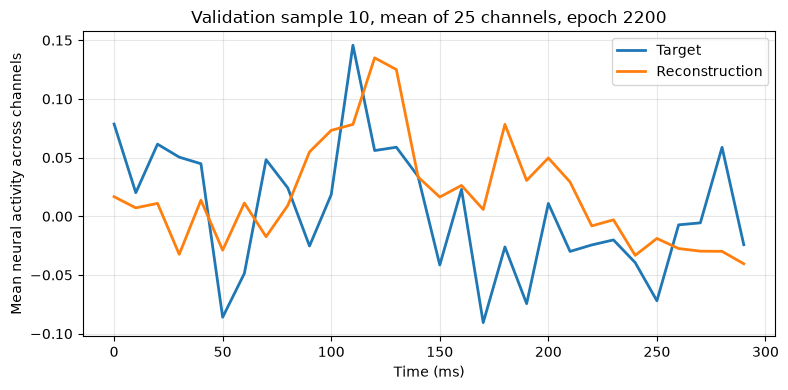

epoch 2201/5000 | train 0.037258 | validation 0.049193
epoch 2202/5000 | train 0.037247 | validation 0.049323
epoch 2203/5000 | train 0.037304 | validation 0.048800
epoch 2204/5000 | train 0.037230 | validation 0.049127
epoch 2205/5000 | train 0.037178 | validation 0.049245
epoch 2206/5000 | train 0.037157 | validation 0.049235
epoch 2207/5000 | train 0.037168 | validation 0.049021
epoch 2208/5000 | train 0.037140 | validation 0.048888
epoch 2209/5000 | train 0.037135 | validation 0.049082
epoch 2210/5000 | train 0.037140 | validation 0.048949
epoch 2211/5000 | train 0.037341 | validation 0.048686
epoch 2212/5000 | train 0.037294 | validation 0.048835
epoch 2213/5000 | train 0.037290 | validation 0.049018
epoch 2214/5000 | train 0.037241 | validation 0.048688
epoch 2215/5000 | train 0.037297 | validation 0.048542
epoch 2216/5000 | train 0.037468 | validation 0.049031
epoch 2217/5000 | train 0.037277 | validation 0.049206
epoch 2218/5000 | train 0.037168 | validation 0.049508
epoch 2219

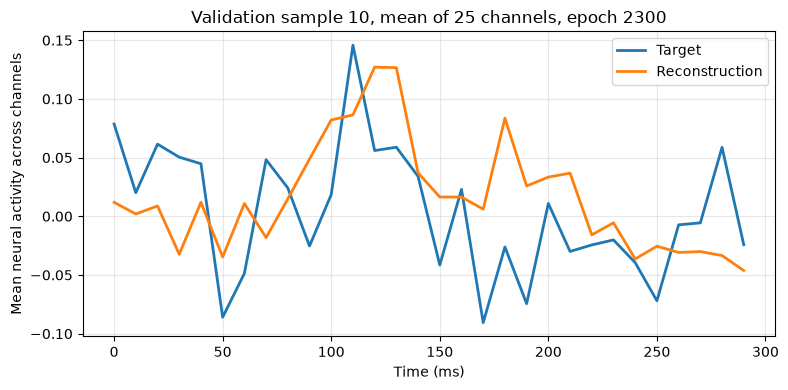

epoch 2301/5000 | train 0.037094 | validation 0.049816
epoch 2302/5000 | train 0.037196 | validation 0.049345
epoch 2303/5000 | train 0.037276 | validation 0.049190
epoch 2304/5000 | train 0.037189 | validation 0.050004
epoch 2305/5000 | train 0.037194 | validation 0.049442
epoch 2306/5000 | train 0.037247 | validation 0.049092
epoch 2307/5000 | train 0.037215 | validation 0.048582
epoch 2308/5000 | train 0.037333 | validation 0.049474
epoch 2309/5000 | train 0.037434 | validation 0.049186
epoch 2310/5000 | train 0.037298 | validation 0.048753
epoch 2311/5000 | train 0.037284 | validation 0.049008
epoch 2312/5000 | train 0.037242 | validation 0.048973
epoch 2313/5000 | train 0.037251 | validation 0.049048
epoch 2314/5000 | train 0.037201 | validation 0.049027
epoch 2315/5000 | train 0.037205 | validation 0.049243
epoch 2316/5000 | train 0.037127 | validation 0.049411
epoch 2317/5000 | train 0.037126 | validation 0.049467
epoch 2318/5000 | train 0.037134 | validation 0.049426
epoch 2319

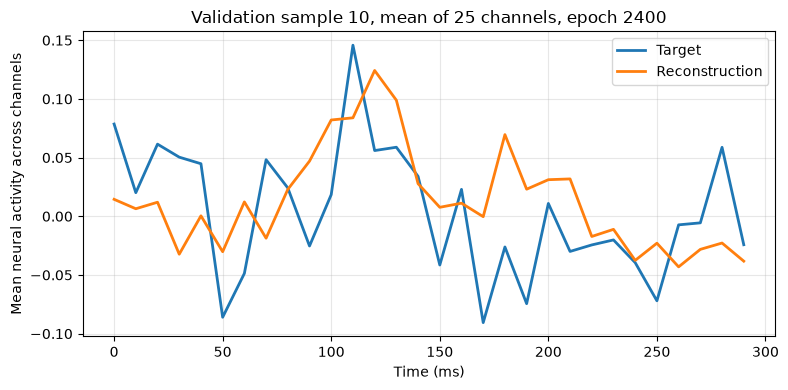

epoch 2401/5000 | train 0.037446 | validation 0.048211
epoch 2402/5000 | train 0.037376 | validation 0.048126
epoch 2403/5000 | train 0.037250 | validation 0.048281
epoch 2404/5000 | train 0.037431 | validation 0.048106
epoch 2405/5000 | train 0.037550 | validation 0.048291
epoch 2406/5000 | train 0.037404 | validation 0.048385
epoch 2407/5000 | train 0.037838 | validation 0.048143
epoch 2408/5000 | train 0.037930 | validation 0.048130
epoch 2409/5000 | train 0.037649 | validation 0.048205
epoch 2410/5000 | train 0.037455 | validation 0.048497
epoch 2411/5000 | train 0.037349 | validation 0.048332
epoch 2412/5000 | train 0.037329 | validation 0.048552
epoch 2413/5000 | train 0.037280 | validation 0.048523
epoch 2414/5000 | train 0.037212 | validation 0.048674
epoch 2415/5000 | train 0.037191 | validation 0.048587
epoch 2416/5000 | train 0.037200 | validation 0.048520
epoch 2417/5000 | train 0.037232 | validation 0.048862
epoch 2418/5000 | train 0.037181 | validation 0.048671
epoch 2419

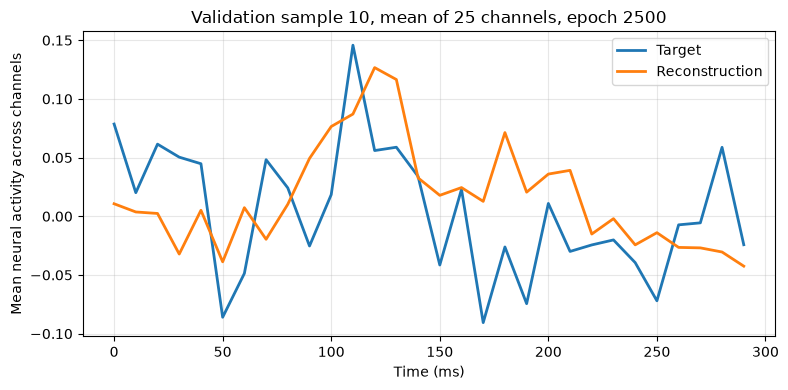

epoch 2501/5000 | train 0.037007 | validation 0.048308
epoch 2502/5000 | train 0.036968 | validation 0.048632
epoch 2503/5000 | train 0.036945 | validation 0.048507
epoch 2504/5000 | train 0.036936 | validation 0.048539
epoch 2505/5000 | train 0.036934 | validation 0.048649
epoch 2506/5000 | train 0.036866 | validation 0.048638
epoch 2507/5000 | train 0.036918 | validation 0.048605
epoch 2508/5000 | train 0.036908 | validation 0.048467
epoch 2509/5000 | train 0.036918 | validation 0.048552
epoch 2510/5000 | train 0.036887 | validation 0.048598
epoch 2511/5000 | train 0.036884 | validation 0.048675
epoch 2512/5000 | train 0.036868 | validation 0.048555
epoch 2513/5000 | train 0.036849 | validation 0.048567
epoch 2514/5000 | train 0.036804 | validation 0.048829
epoch 2515/5000 | train 0.036941 | validation 0.048623
epoch 2516/5000 | train 0.036923 | validation 0.048461
epoch 2517/5000 | train 0.036877 | validation 0.048792
epoch 2518/5000 | train 0.036817 | validation 0.048539
epoch 2519

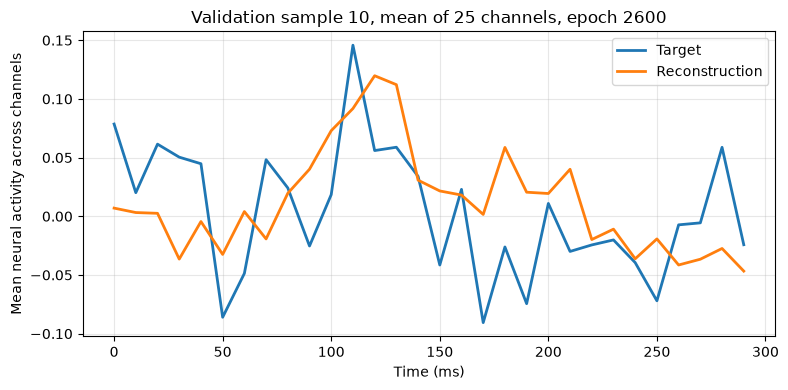

epoch 2601/5000 | train 0.036798 | validation 0.048618
epoch 2602/5000 | train 0.036842 | validation 0.048498
epoch 2603/5000 | train 0.036844 | validation 0.048646
epoch 2604/5000 | train 0.036901 | validation 0.048504
epoch 2605/5000 | train 0.036830 | validation 0.048529
epoch 2606/5000 | train 0.037071 | validation 0.048495
epoch 2607/5000 | train 0.037307 | validation 0.048162
epoch 2608/5000 | train 0.037397 | validation 0.048126
epoch 2609/5000 | train 0.037182 | validation 0.048390
epoch 2610/5000 | train 0.037076 | validation 0.048503
epoch 2611/5000 | train 0.037001 | validation 0.048267
epoch 2612/5000 | train 0.036995 | validation 0.048360
epoch 2613/5000 | train 0.037006 | validation 0.048386
epoch 2614/5000 | train 0.036925 | validation 0.048578
epoch 2615/5000 | train 0.036886 | validation 0.048787
epoch 2616/5000 | train 0.036916 | validation 0.048886
epoch 2617/5000 | train 0.036870 | validation 0.049092
epoch 2618/5000 | train 0.036884 | validation 0.049050
epoch 2619

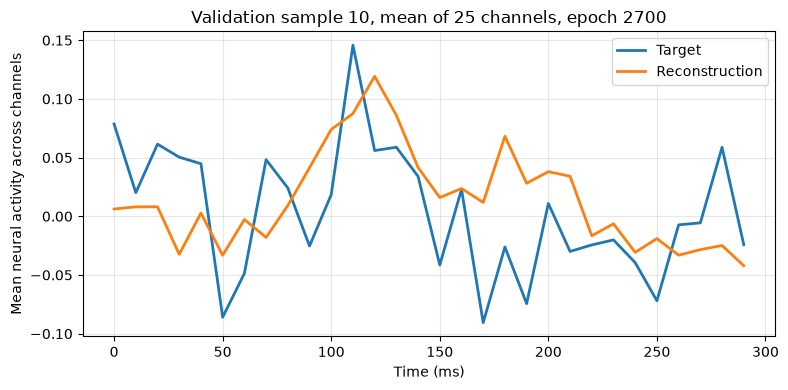

epoch 2701/5000 | train 0.036785 | validation 0.048447
epoch 2702/5000 | train 0.036734 | validation 0.048586
epoch 2703/5000 | train 0.036944 | validation 0.048302
epoch 2704/5000 | train 0.037069 | validation 0.048442
epoch 2705/5000 | train 0.036897 | validation 0.048636
epoch 2706/5000 | train 0.036799 | validation 0.048659
epoch 2707/5000 | train 0.036724 | validation 0.048645
epoch 2708/5000 | train 0.037097 | validation 0.048498
epoch 2709/5000 | train 0.037223 | validation 0.048275
epoch 2710/5000 | train 0.037205 | validation 0.048437
epoch 2711/5000 | train 0.037034 | validation 0.048566
epoch 2712/5000 | train 0.036845 | validation 0.048479
epoch 2713/5000 | train 0.036849 | validation 0.048534
epoch 2714/5000 | train 0.037136 | validation 0.048467
epoch 2715/5000 | train 0.036924 | validation 0.048473
epoch 2716/5000 | train 0.036798 | validation 0.048448
epoch 2717/5000 | train 0.036976 | validation 0.048529
epoch 2718/5000 | train 0.036961 | validation 0.048623
epoch 2719

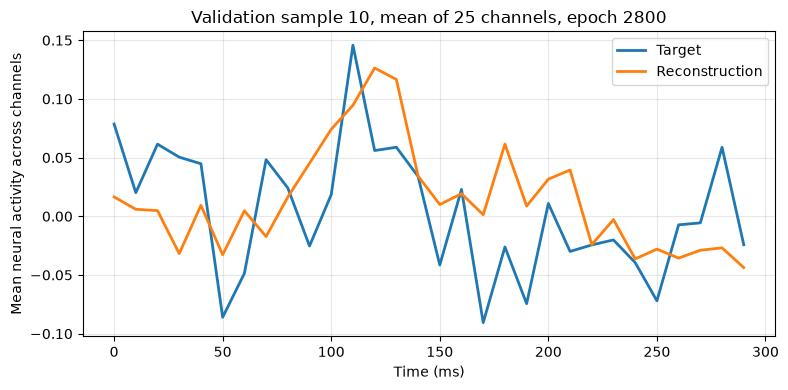

epoch 2801/5000 | train 0.036727 | validation 0.049512
epoch 2802/5000 | train 0.036680 | validation 0.049457
epoch 2803/5000 | train 0.036677 | validation 0.049545
epoch 2804/5000 | train 0.036973 | validation 0.048748
epoch 2805/5000 | train 0.037057 | validation 0.049292
epoch 2806/5000 | train 0.037030 | validation 0.049217
epoch 2807/5000 | train 0.037060 | validation 0.049749
epoch 2808/5000 | train 0.036964 | validation 0.050396
epoch 2809/5000 | train 0.036790 | validation 0.051165
epoch 2810/5000 | train 0.036890 | validation 0.050465
epoch 2811/5000 | train 0.037092 | validation 0.049737
epoch 2812/5000 | train 0.036974 | validation 0.049615
epoch 2813/5000 | train 0.037237 | validation 0.049954
epoch 2814/5000 | train 0.037368 | validation 0.049652
epoch 2815/5000 | train 0.037303 | validation 0.049613
epoch 2816/5000 | train 0.037357 | validation 0.048974
epoch 2817/5000 | train 0.037147 | validation 0.048947
epoch 2818/5000 | train 0.037091 | validation 0.048792
epoch 2819

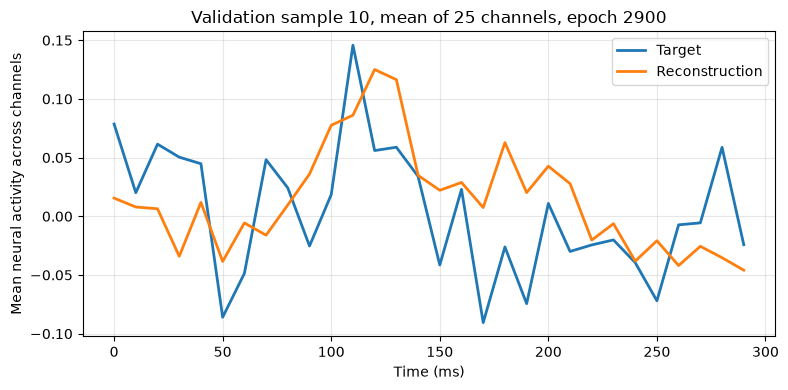

epoch 2901/5000 | train 0.037084 | validation 0.048722
epoch 2902/5000 | train 0.037263 | validation 0.048682
epoch 2903/5000 | train 0.037173 | validation 0.048716
epoch 2904/5000 | train 0.037326 | validation 0.048241
epoch 2905/5000 | train 0.037341 | validation 0.048339
epoch 2906/5000 | train 0.037169 | validation 0.048654
epoch 2907/5000 | train 0.036992 | validation 0.048773
epoch 2908/5000 | train 0.036937 | validation 0.049055
epoch 2909/5000 | train 0.036881 | validation 0.049248
epoch 2910/5000 | train 0.036816 | validation 0.049284
epoch 2911/5000 | train 0.036805 | validation 0.049514
epoch 2912/5000 | train 0.036774 | validation 0.049741
epoch 2913/5000 | train 0.036804 | validation 0.049721
epoch 2914/5000 | train 0.036759 | validation 0.049621
epoch 2915/5000 | train 0.036739 | validation 0.049520
epoch 2916/5000 | train 0.036877 | validation 0.048819
epoch 2917/5000 | train 0.036844 | validation 0.048704
epoch 2918/5000 | train 0.036763 | validation 0.048913
epoch 2919

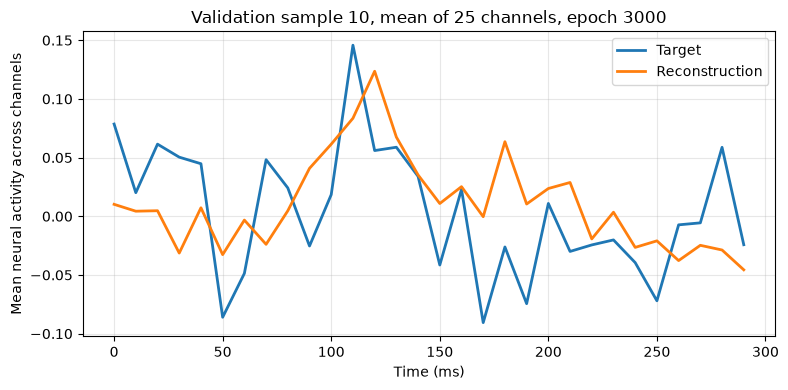

epoch 3001/5000 | train 0.037021 | validation 0.048471
epoch 3002/5000 | train 0.037053 | validation 0.048521
epoch 3003/5000 | train 0.036965 | validation 0.048464
epoch 3004/5000 | train 0.036967 | validation 0.048619
epoch 3005/5000 | train 0.036887 | validation 0.048527
epoch 3006/5000 | train 0.036877 | validation 0.048432
epoch 3007/5000 | train 0.036785 | validation 0.048519
epoch 3008/5000 | train 0.036774 | validation 0.048556
epoch 3009/5000 | train 0.036781 | validation 0.048453
epoch 3010/5000 | train 0.036720 | validation 0.048473
epoch 3011/5000 | train 0.036752 | validation 0.048526
epoch 3012/5000 | train 0.036755 | validation 0.048590
epoch 3013/5000 | train 0.036882 | validation 0.048502
epoch 3014/5000 | train 0.036769 | validation 0.048542
epoch 3015/5000 | train 0.036757 | validation 0.048572
epoch 3016/5000 | train 0.036723 | validation 0.048779
epoch 3017/5000 | train 0.036648 | validation 0.048712
epoch 3018/5000 | train 0.036693 | validation 0.048699
epoch 3019

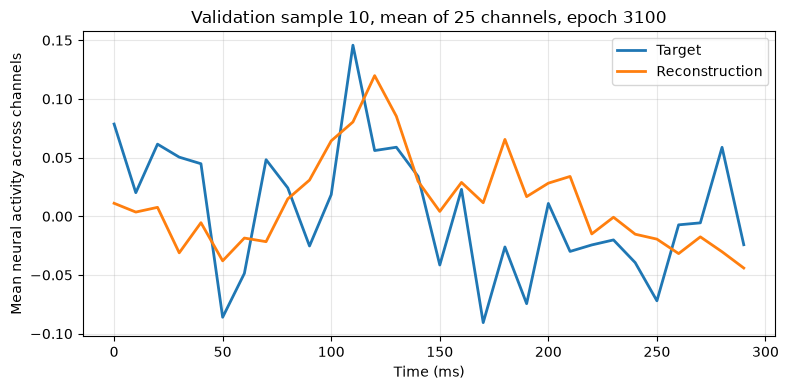

epoch 3101/5000 | train 0.036699 | validation 0.048729
epoch 3102/5000 | train 0.036716 | validation 0.048494
epoch 3103/5000 | train 0.036760 | validation 0.048537
epoch 3104/5000 | train 0.036726 | validation 0.048653
epoch 3105/5000 | train 0.036625 | validation 0.048521
epoch 3106/5000 | train 0.036721 | validation 0.048435
epoch 3107/5000 | train 0.036772 | validation 0.048559
epoch 3108/5000 | train 0.036720 | validation 0.048735
epoch 3109/5000 | train 0.036605 | validation 0.048801
epoch 3110/5000 | train 0.036617 | validation 0.048767
epoch 3111/5000 | train 0.036576 | validation 0.048778
epoch 3112/5000 | train 0.036611 | validation 0.049007
epoch 3113/5000 | train 0.036488 | validation 0.048942
epoch 3114/5000 | train 0.036510 | validation 0.049125
epoch 3115/5000 | train 0.036527 | validation 0.049075
epoch 3116/5000 | train 0.036567 | validation 0.049439
epoch 3117/5000 | train 0.036921 | validation 0.048650
epoch 3118/5000 | train 0.036730 | validation 0.048704
epoch 3119

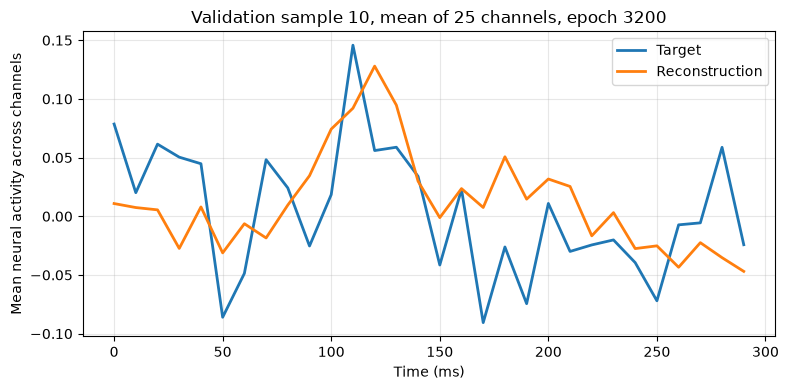

epoch 3201/5000 | train 0.036729 | validation 0.048766
epoch 3202/5000 | train 0.036594 | validation 0.048707
epoch 3203/5000 | train 0.036590 | validation 0.048909
epoch 3204/5000 | train 0.036539 | validation 0.048816
epoch 3205/5000 | train 0.036493 | validation 0.048895
epoch 3206/5000 | train 0.036476 | validation 0.048939
epoch 3207/5000 | train 0.036561 | validation 0.048814
epoch 3208/5000 | train 0.036617 | validation 0.048588
epoch 3209/5000 | train 0.036645 | validation 0.048878
epoch 3210/5000 | train 0.036620 | validation 0.048744
epoch 3211/5000 | train 0.036530 | validation 0.048850
epoch 3212/5000 | train 0.036575 | validation 0.048945
epoch 3213/5000 | train 0.036519 | validation 0.048941
epoch 3214/5000 | train 0.036571 | validation 0.048799
epoch 3215/5000 | train 0.036508 | validation 0.048790
epoch 3216/5000 | train 0.036477 | validation 0.048785
epoch 3217/5000 | train 0.036570 | validation 0.048572
epoch 3218/5000 | train 0.036656 | validation 0.048582
epoch 3219

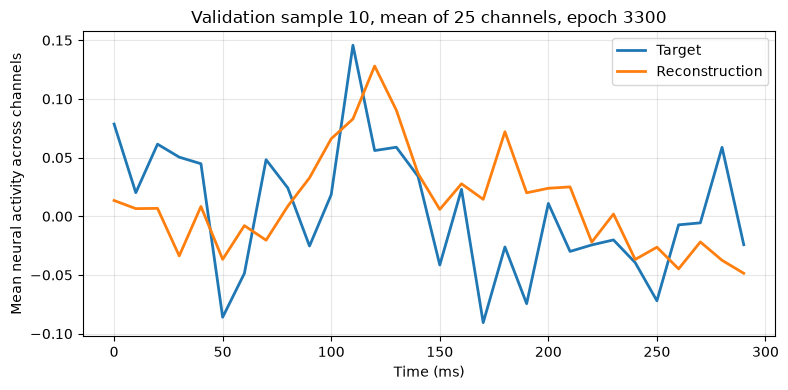

epoch 3301/5000 | train 0.036425 | validation 0.049616
epoch 3302/5000 | train 0.036523 | validation 0.049907
epoch 3303/5000 | train 0.036466 | validation 0.049827
epoch 3304/5000 | train 0.036418 | validation 0.049828
epoch 3305/5000 | train 0.036477 | validation 0.049928
epoch 3306/5000 | train 0.036572 | validation 0.049781
epoch 3307/5000 | train 0.036527 | validation 0.048586
epoch 3308/5000 | train 0.037115 | validation 0.048560
epoch 3309/5000 | train 0.037021 | validation 0.048606
epoch 3310/5000 | train 0.036786 | validation 0.048679
epoch 3311/5000 | train 0.036758 | validation 0.048810
epoch 3312/5000 | train 0.036639 | validation 0.048822
epoch 3313/5000 | train 0.036592 | validation 0.048595
epoch 3314/5000 | train 0.036647 | validation 0.048884
epoch 3315/5000 | train 0.036564 | validation 0.048459
epoch 3316/5000 | train 0.036678 | validation 0.048892
epoch 3317/5000 | train 0.037016 | validation 0.048664
epoch 3318/5000 | train 0.037165 | validation 0.048577
epoch 3319

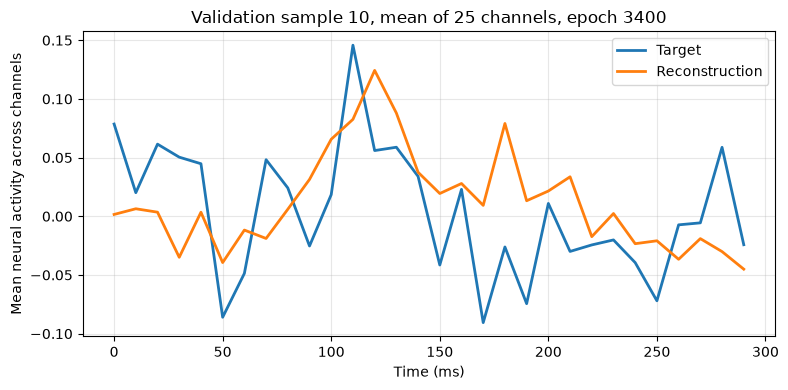

epoch 3401/5000 | train 0.036813 | validation 0.048525
epoch 3402/5000 | train 0.036937 | validation 0.048490
epoch 3403/5000 | train 0.036981 | validation 0.048611
epoch 3404/5000 | train 0.036939 | validation 0.048848
epoch 3405/5000 | train 0.036743 | validation 0.048966
epoch 3406/5000 | train 0.036686 | validation 0.048963
epoch 3407/5000 | train 0.036595 | validation 0.049050
epoch 3408/5000 | train 0.036624 | validation 0.048994
epoch 3409/5000 | train 0.036579 | validation 0.049033
epoch 3410/5000 | train 0.036571 | validation 0.049288
epoch 3411/5000 | train 0.036680 | validation 0.049007
epoch 3412/5000 | train 0.036571 | validation 0.048516
epoch 3413/5000 | train 0.036992 | validation 0.048507
epoch 3414/5000 | train 0.036981 | validation 0.048579
epoch 3415/5000 | train 0.036865 | validation 0.048868
epoch 3416/5000 | train 0.036731 | validation 0.049066
epoch 3417/5000 | train 0.036606 | validation 0.049320
epoch 3418/5000 | train 0.036593 | validation 0.049016
epoch 3419

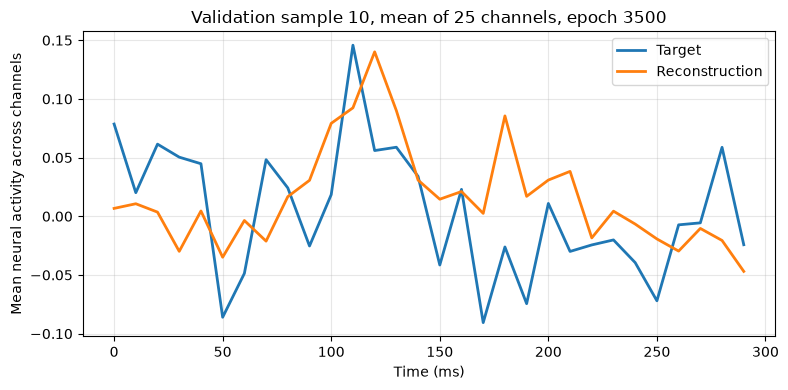

epoch 3501/5000 | train 0.036811 | validation 0.048686
epoch 3502/5000 | train 0.036717 | validation 0.048817
epoch 3503/5000 | train 0.036632 | validation 0.048790
epoch 3504/5000 | train 0.036515 | validation 0.048839
epoch 3505/5000 | train 0.036520 | validation 0.048850
epoch 3506/5000 | train 0.036485 | validation 0.049070
epoch 3507/5000 | train 0.036506 | validation 0.048980
epoch 3508/5000 | train 0.036475 | validation 0.049036
epoch 3509/5000 | train 0.036442 | validation 0.048911
epoch 3510/5000 | train 0.036481 | validation 0.049054
epoch 3511/5000 | train 0.036422 | validation 0.049023
epoch 3512/5000 | train 0.036406 | validation 0.049119
epoch 3513/5000 | train 0.036410 | validation 0.048800
epoch 3514/5000 | train 0.036532 | validation 0.048956
epoch 3515/5000 | train 0.036435 | validation 0.049419
epoch 3516/5000 | train 0.036634 | validation 0.049073
epoch 3517/5000 | train 0.036532 | validation 0.049324
epoch 3518/5000 | train 0.036666 | validation 0.048805
epoch 3519

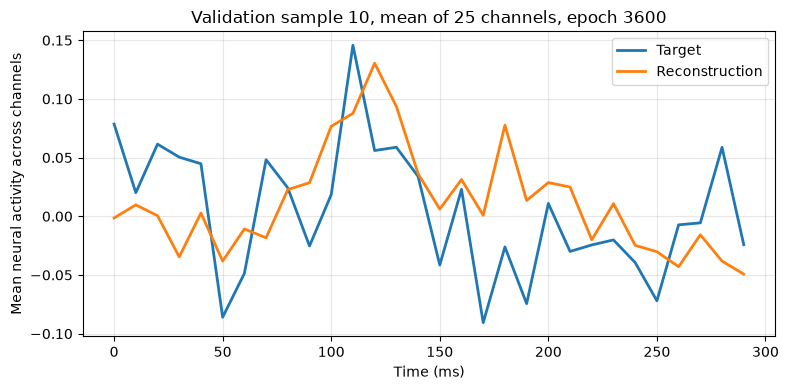

epoch 3601/5000 | train 0.036395 | validation 0.051490
epoch 3602/5000 | train 0.036392 | validation 0.051366
epoch 3603/5000 | train 0.036390 | validation 0.051025
epoch 3604/5000 | train 0.036400 | validation 0.050943
epoch 3605/5000 | train 0.036477 | validation 0.050944
epoch 3606/5000 | train 0.036456 | validation 0.051368
epoch 3607/5000 | train 0.036417 | validation 0.051059
epoch 3608/5000 | train 0.036428 | validation 0.051575
epoch 3609/5000 | train 0.036451 | validation 0.051391
epoch 3610/5000 | train 0.036381 | validation 0.051220
epoch 3611/5000 | train 0.036353 | validation 0.051505
epoch 3612/5000 | train 0.036322 | validation 0.051383
epoch 3613/5000 | train 0.036354 | validation 0.051479
epoch 3614/5000 | train 0.036328 | validation 0.051173
epoch 3615/5000 | train 0.036378 | validation 0.051135
epoch 3616/5000 | train 0.036467 | validation 0.051658
epoch 3617/5000 | train 0.036380 | validation 0.051219
epoch 3618/5000 | train 0.036293 | validation 0.051665
epoch 3619

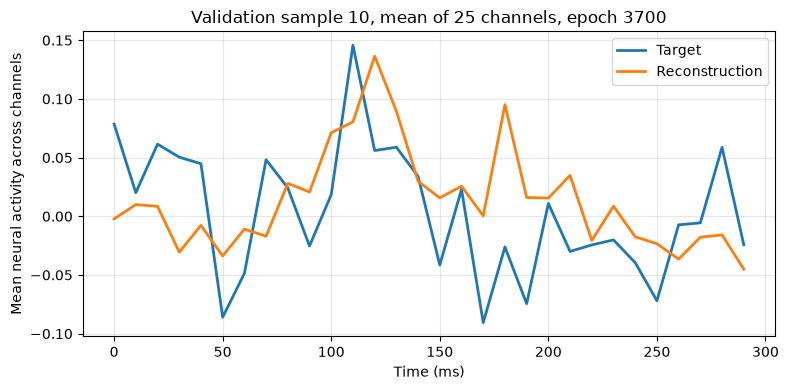

epoch 3701/5000 | train 0.036359 | validation 0.052468
epoch 3702/5000 | train 0.036617 | validation 0.051392
epoch 3703/5000 | train 0.037032 | validation 0.050293
epoch 3704/5000 | train 0.037232 | validation 0.050126
epoch 3705/5000 | train 0.037023 | validation 0.051072
epoch 3706/5000 | train 0.036996 | validation 0.050945
epoch 3707/5000 | train 0.036832 | validation 0.051398
epoch 3708/5000 | train 0.036817 | validation 0.051528
epoch 3709/5000 | train 0.036758 | validation 0.051434
epoch 3710/5000 | train 0.036653 | validation 0.051127
epoch 3711/5000 | train 0.036833 | validation 0.050976
epoch 3712/5000 | train 0.036718 | validation 0.050810
epoch 3713/5000 | train 0.036606 | validation 0.050883
epoch 3714/5000 | train 0.036612 | validation 0.051114
epoch 3715/5000 | train 0.036580 | validation 0.051517
epoch 3716/5000 | train 0.036524 | validation 0.051904
epoch 3717/5000 | train 0.036489 | validation 0.051724
epoch 3718/5000 | train 0.036440 | validation 0.052354
epoch 3719

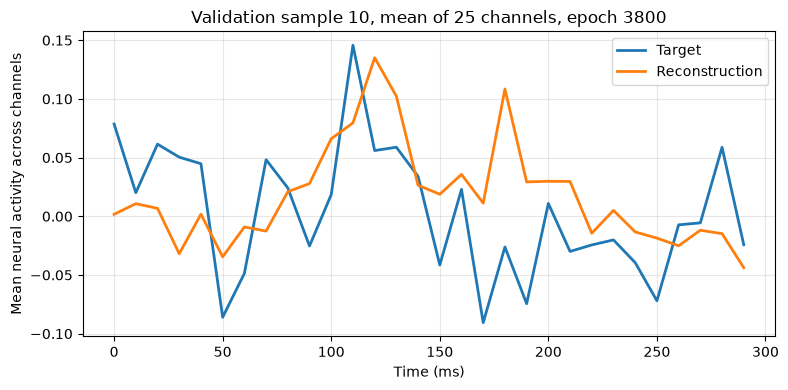

epoch 3801/5000 | train 0.036477 | validation 0.049675
epoch 3802/5000 | train 0.036373 | validation 0.049732
epoch 3803/5000 | train 0.036404 | validation 0.049568
epoch 3804/5000 | train 0.036479 | validation 0.049575
epoch 3805/5000 | train 0.036396 | validation 0.049691
epoch 3806/5000 | train 0.036374 | validation 0.049679
epoch 3807/5000 | train 0.036374 | validation 0.049781
epoch 3808/5000 | train 0.036417 | validation 0.050042
epoch 3809/5000 | train 0.036469 | validation 0.049916
epoch 3810/5000 | train 0.036348 | validation 0.049997
epoch 3811/5000 | train 0.036418 | validation 0.049218
epoch 3812/5000 | train 0.036401 | validation 0.049463
epoch 3813/5000 | train 0.036341 | validation 0.049526
epoch 3814/5000 | train 0.036368 | validation 0.049762
epoch 3815/5000 | train 0.036319 | validation 0.050042
epoch 3816/5000 | train 0.036331 | validation 0.050150
epoch 3817/5000 | train 0.036349 | validation 0.050102
epoch 3818/5000 | train 0.036241 | validation 0.050320
epoch 3819

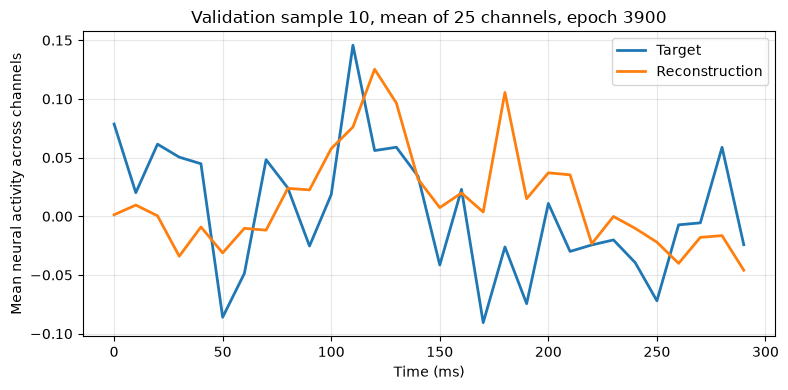

epoch 3901/5000 | train 0.037050 | validation 0.049989
epoch 3902/5000 | train 0.036983 | validation 0.050555
epoch 3903/5000 | train 0.036973 | validation 0.050529
epoch 3904/5000 | train 0.036993 | validation 0.049830
epoch 3905/5000 | train 0.036947 | validation 0.049551
epoch 3906/5000 | train 0.036872 | validation 0.049753
epoch 3907/5000 | train 0.036779 | validation 0.049722
epoch 3908/5000 | train 0.036830 | validation 0.050043
epoch 3909/5000 | train 0.036788 | validation 0.050379
epoch 3910/5000 | train 0.036799 | validation 0.050341
epoch 3911/5000 | train 0.036751 | validation 0.050764
epoch 3912/5000 | train 0.036704 | validation 0.050237
epoch 3913/5000 | train 0.036644 | validation 0.050658
epoch 3914/5000 | train 0.036853 | validation 0.049463
epoch 3915/5000 | train 0.036929 | validation 0.048987
epoch 3916/5000 | train 0.036913 | validation 0.049379
epoch 3917/5000 | train 0.036825 | validation 0.049829
epoch 3918/5000 | train 0.036659 | validation 0.049964
epoch 3919

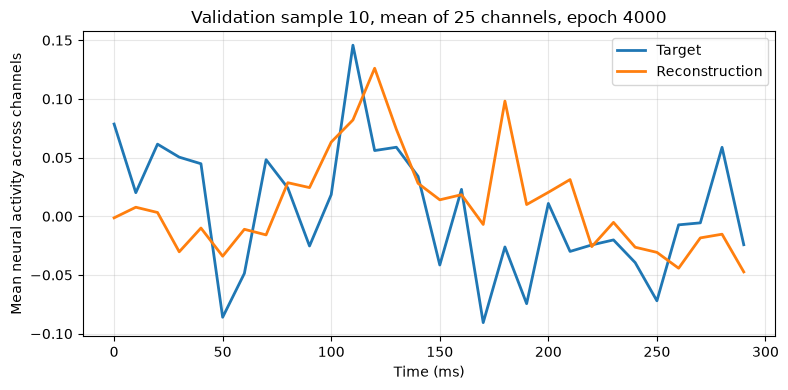

epoch 4001/5000 | train 0.036284 | validation 0.054163
epoch 4002/5000 | train 0.036256 | validation 0.054186
epoch 4003/5000 | train 0.036226 | validation 0.054405
epoch 4004/5000 | train 0.036206 | validation 0.054031
epoch 4005/5000 | train 0.036240 | validation 0.054307
epoch 4006/5000 | train 0.036184 | validation 0.054709
epoch 4007/5000 | train 0.036302 | validation 0.054696
epoch 4008/5000 | train 0.036229 | validation 0.054015
epoch 4009/5000 | train 0.036216 | validation 0.053546
epoch 4010/5000 | train 0.036205 | validation 0.053255
epoch 4011/5000 | train 0.036240 | validation 0.051794
epoch 4012/5000 | train 0.036258 | validation 0.052595
epoch 4013/5000 | train 0.036184 | validation 0.052526
epoch 4014/5000 | train 0.036236 | validation 0.052520
epoch 4015/5000 | train 0.036113 | validation 0.053046
epoch 4016/5000 | train 0.036155 | validation 0.052740
epoch 4017/5000 | train 0.036186 | validation 0.052690
epoch 4018/5000 | train 0.036186 | validation 0.052441
epoch 4019

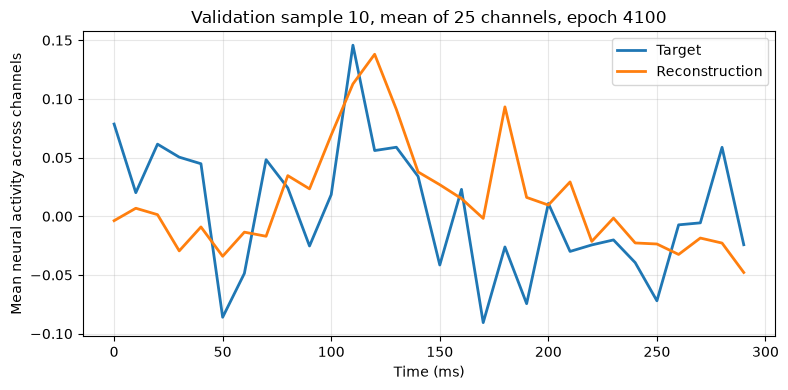

epoch 4101/5000 | train 0.036489 | validation 0.051335
epoch 4102/5000 | train 0.036374 | validation 0.051794
epoch 4103/5000 | train 0.036294 | validation 0.052024
epoch 4104/5000 | train 0.036297 | validation 0.051552
epoch 4105/5000 | train 0.036284 | validation 0.052171
epoch 4106/5000 | train 0.036279 | validation 0.052838
epoch 4107/5000 | train 0.036192 | validation 0.051534
epoch 4108/5000 | train 0.036232 | validation 0.051245
epoch 4109/5000 | train 0.036215 | validation 0.051473
epoch 4110/5000 | train 0.036161 | validation 0.051604
epoch 4111/5000 | train 0.036165 | validation 0.051733
epoch 4112/5000 | train 0.036220 | validation 0.051711
epoch 4113/5000 | train 0.036186 | validation 0.051799
epoch 4114/5000 | train 0.036078 | validation 0.051631
epoch 4115/5000 | train 0.036108 | validation 0.051816
epoch 4116/5000 | train 0.036145 | validation 0.051951
epoch 4117/5000 | train 0.036151 | validation 0.052078
epoch 4118/5000 | train 0.036188 | validation 0.051791
epoch 4119

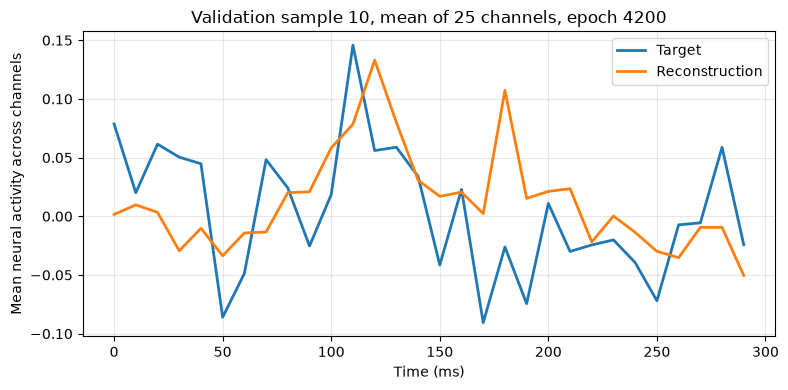

epoch 4201/5000 | train 0.036132 | validation 0.049529
epoch 4202/5000 | train 0.036058 | validation 0.049966
epoch 4203/5000 | train 0.036258 | validation 0.049481
epoch 4204/5000 | train 0.036192 | validation 0.049616
epoch 4205/5000 | train 0.036091 | validation 0.049900
epoch 4206/5000 | train 0.036213 | validation 0.049652
epoch 4207/5000 | train 0.036145 | validation 0.050022
epoch 4208/5000 | train 0.036155 | validation 0.050154
epoch 4209/5000 | train 0.036120 | validation 0.050444
epoch 4210/5000 | train 0.036127 | validation 0.050001
epoch 4211/5000 | train 0.036257 | validation 0.050036
epoch 4212/5000 | train 0.036231 | validation 0.050094
epoch 4213/5000 | train 0.036107 | validation 0.050317
epoch 4214/5000 | train 0.036141 | validation 0.050202
epoch 4215/5000 | train 0.036097 | validation 0.050343
epoch 4216/5000 | train 0.036102 | validation 0.050680
epoch 4217/5000 | train 0.036131 | validation 0.050212
epoch 4218/5000 | train 0.036121 | validation 0.050320
epoch 4219

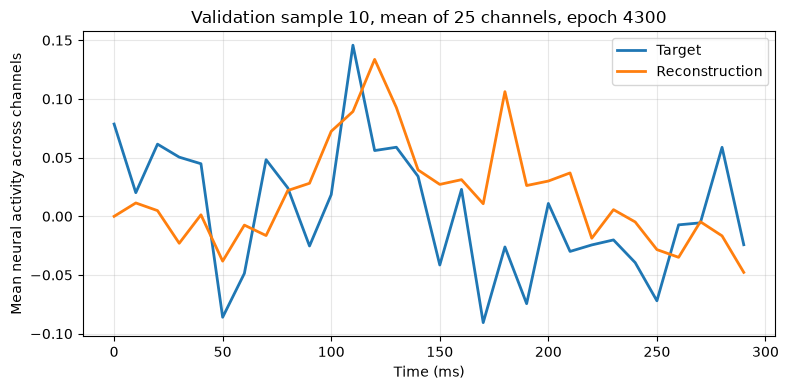

epoch 4301/5000 | train 0.036223 | validation 0.051219
epoch 4302/5000 | train 0.036211 | validation 0.051304
epoch 4303/5000 | train 0.036095 | validation 0.051664
epoch 4304/5000 | train 0.036139 | validation 0.051137
epoch 4305/5000 | train 0.036142 | validation 0.050837
epoch 4306/5000 | train 0.036136 | validation 0.051065
epoch 4307/5000 | train 0.036139 | validation 0.051150
epoch 4308/5000 | train 0.036137 | validation 0.051072
epoch 4309/5000 | train 0.036113 | validation 0.051110
epoch 4310/5000 | train 0.036115 | validation 0.051579
epoch 4311/5000 | train 0.036132 | validation 0.051157
epoch 4312/5000 | train 0.036106 | validation 0.051072
epoch 4313/5000 | train 0.036067 | validation 0.051077
epoch 4314/5000 | train 0.036027 | validation 0.051207
epoch 4315/5000 | train 0.036103 | validation 0.051377
epoch 4316/5000 | train 0.036161 | validation 0.051064
epoch 4317/5000 | train 0.036149 | validation 0.051100
epoch 4318/5000 | train 0.036168 | validation 0.050278
epoch 4319

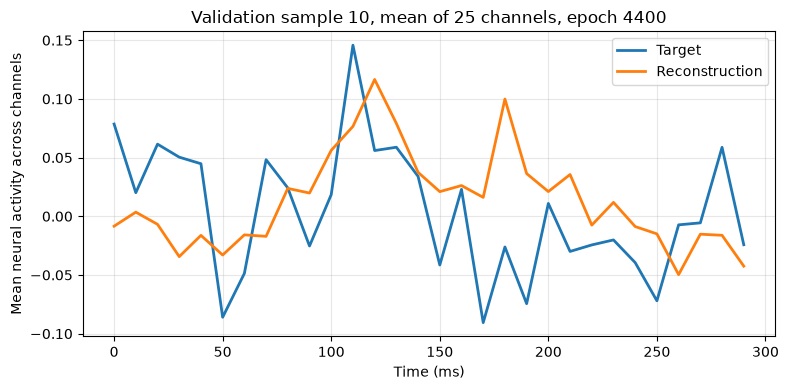

epoch 4401/5000 | train 0.036360 | validation 0.051380
epoch 4402/5000 | train 0.036154 | validation 0.051785
epoch 4403/5000 | train 0.036199 | validation 0.051365
epoch 4404/5000 | train 0.036052 | validation 0.051281
epoch 4405/5000 | train 0.036111 | validation 0.051340
epoch 4406/5000 | train 0.036067 | validation 0.051756
epoch 4407/5000 | train 0.036063 | validation 0.052029
epoch 4408/5000 | train 0.036065 | validation 0.052218
epoch 4409/5000 | train 0.036034 | validation 0.051794
epoch 4410/5000 | train 0.036121 | validation 0.051761
epoch 4411/5000 | train 0.036042 | validation 0.052194
epoch 4412/5000 | train 0.035995 | validation 0.052001
epoch 4413/5000 | train 0.036106 | validation 0.051517
epoch 4414/5000 | train 0.036170 | validation 0.051197
epoch 4415/5000 | train 0.036125 | validation 0.051999
epoch 4416/5000 | train 0.036078 | validation 0.052092
epoch 4417/5000 | train 0.036073 | validation 0.051798
epoch 4418/5000 | train 0.036100 | validation 0.052041
epoch 4419

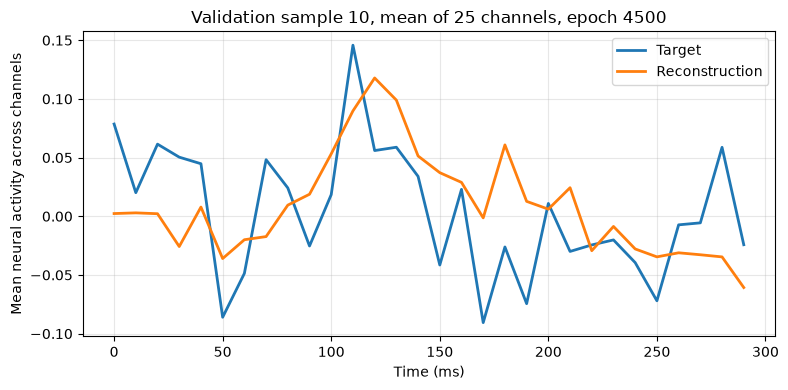

epoch 4501/5000 | train 0.037158 | validation 0.050233
epoch 4502/5000 | train 0.036997 | validation 0.050436
epoch 4503/5000 | train 0.036813 | validation 0.051170
epoch 4504/5000 | train 0.036745 | validation 0.051102
epoch 4505/5000 | train 0.036679 | validation 0.051814
epoch 4506/5000 | train 0.036643 | validation 0.051689
epoch 4507/5000 | train 0.036597 | validation 0.052466
epoch 4508/5000 | train 0.036510 | validation 0.052380
epoch 4509/5000 | train 0.036498 | validation 0.051947
epoch 4510/5000 | train 0.036424 | validation 0.052307
epoch 4511/5000 | train 0.036393 | validation 0.052310
epoch 4512/5000 | train 0.036314 | validation 0.052349
epoch 4513/5000 | train 0.036586 | validation 0.051965
epoch 4514/5000 | train 0.036418 | validation 0.051047
epoch 4515/5000 | train 0.036453 | validation 0.051179
epoch 4516/5000 | train 0.036322 | validation 0.051050
epoch 4517/5000 | train 0.036420 | validation 0.050246
epoch 4518/5000 | train 0.036879 | validation 0.049807
epoch 4519

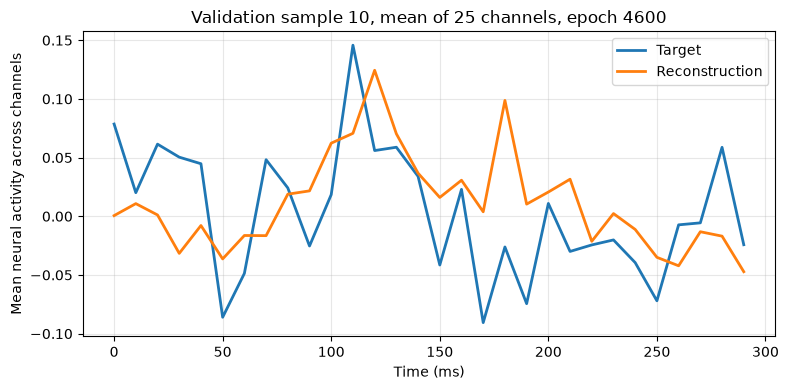

epoch 4601/5000 | train 0.037219 | validation 0.050602
epoch 4602/5000 | train 0.037243 | validation 0.050024
epoch 4603/5000 | train 0.036957 | validation 0.050159
epoch 4604/5000 | train 0.036752 | validation 0.050640
epoch 4605/5000 | train 0.036616 | validation 0.051322
epoch 4606/5000 | train 0.036490 | validation 0.051225
epoch 4607/5000 | train 0.036625 | validation 0.050933
epoch 4608/5000 | train 0.036545 | validation 0.051501
epoch 4609/5000 | train 0.036393 | validation 0.051556
epoch 4610/5000 | train 0.036306 | validation 0.051183
epoch 4611/5000 | train 0.036238 | validation 0.050723
epoch 4612/5000 | train 0.036249 | validation 0.050933
epoch 4613/5000 | train 0.036193 | validation 0.050932
epoch 4614/5000 | train 0.036161 | validation 0.051287
epoch 4615/5000 | train 0.036131 | validation 0.051395
epoch 4616/5000 | train 0.036134 | validation 0.051180
epoch 4617/5000 | train 0.035999 | validation 0.051377
epoch 4618/5000 | train 0.036053 | validation 0.051430
epoch 4619

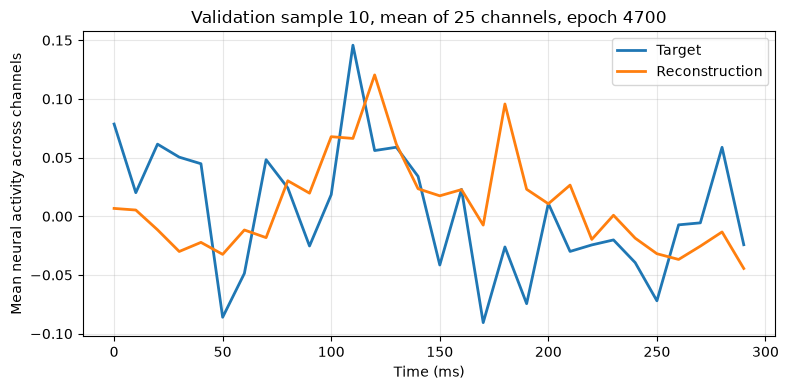

epoch 4701/5000 | train 0.036118 | validation 0.051270
epoch 4702/5000 | train 0.036032 | validation 0.051002
epoch 4703/5000 | train 0.036142 | validation 0.050532
epoch 4704/5000 | train 0.035987 | validation 0.050941
epoch 4705/5000 | train 0.035974 | validation 0.051097
epoch 4706/5000 | train 0.035995 | validation 0.051128
epoch 4707/5000 | train 0.035907 | validation 0.051425
epoch 4708/5000 | train 0.035997 | validation 0.051043
epoch 4709/5000 | train 0.036002 | validation 0.051037
epoch 4710/5000 | train 0.035964 | validation 0.051330
epoch 4711/5000 | train 0.036041 | validation 0.051131
epoch 4712/5000 | train 0.036021 | validation 0.051238
epoch 4713/5000 | train 0.035968 | validation 0.050873
epoch 4714/5000 | train 0.035969 | validation 0.051194
epoch 4715/5000 | train 0.035950 | validation 0.050939
epoch 4716/5000 | train 0.035956 | validation 0.051042
epoch 4717/5000 | train 0.035923 | validation 0.051138
epoch 4718/5000 | train 0.035904 | validation 0.050969
epoch 4719

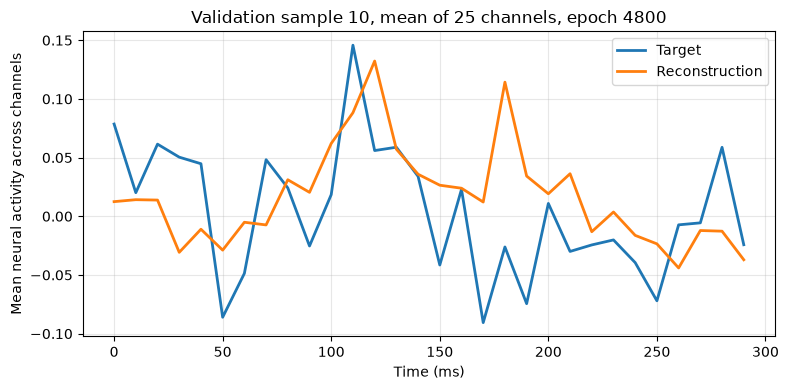

epoch 4801/5000 | train 0.036221 | validation 0.055266
epoch 4802/5000 | train 0.036302 | validation 0.054240
epoch 4803/5000 | train 0.036584 | validation 0.054958
epoch 4804/5000 | train 0.036566 | validation 0.055083
epoch 4805/5000 | train 0.036481 | validation 0.055908
epoch 4806/5000 | train 0.036345 | validation 0.056702
epoch 4807/5000 | train 0.036990 | validation 0.055388
epoch 4808/5000 | train 0.036867 | validation 0.054265
epoch 4809/5000 | train 0.036747 | validation 0.054532
epoch 4810/5000 | train 0.036579 | validation 0.053877
epoch 4811/5000 | train 0.036489 | validation 0.053329
epoch 4812/5000 | train 0.038186 | validation 0.052748
epoch 4813/5000 | train 0.037100 | validation 0.051034
epoch 4814/5000 | train 0.037165 | validation 0.051198
epoch 4815/5000 | train 0.036991 | validation 0.051932
epoch 4816/5000 | train 0.036825 | validation 0.052090
epoch 4817/5000 | train 0.036620 | validation 0.052822
epoch 4818/5000 | train 0.036581 | validation 0.053801
epoch 4819

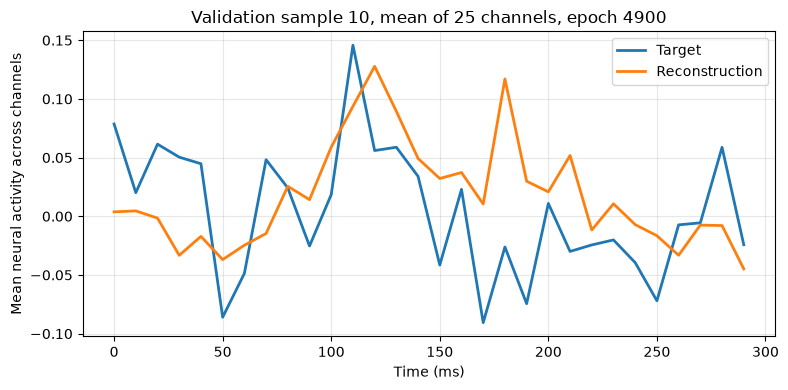

epoch 4901/5000 | train 0.036073 | validation 0.051454
epoch 4902/5000 | train 0.036069 | validation 0.051227
epoch 4903/5000 | train 0.036058 | validation 0.051488
epoch 4904/5000 | train 0.036133 | validation 0.051692
epoch 4905/5000 | train 0.036000 | validation 0.052160
epoch 4906/5000 | train 0.035961 | validation 0.052016
epoch 4907/5000 | train 0.036210 | validation 0.051367
epoch 4908/5000 | train 0.036183 | validation 0.051340
epoch 4909/5000 | train 0.036150 | validation 0.051816
epoch 4910/5000 | train 0.036003 | validation 0.052664
epoch 4911/5000 | train 0.036018 | validation 0.052504
epoch 4912/5000 | train 0.035956 | validation 0.052404
epoch 4913/5000 | train 0.035928 | validation 0.052860
epoch 4914/5000 | train 0.035993 | validation 0.052078
epoch 4915/5000 | train 0.036018 | validation 0.051817
epoch 4916/5000 | train 0.036000 | validation 0.051753
epoch 4917/5000 | train 0.036040 | validation 0.052077
epoch 4918/5000 | train 0.036073 | validation 0.052266
epoch 4919

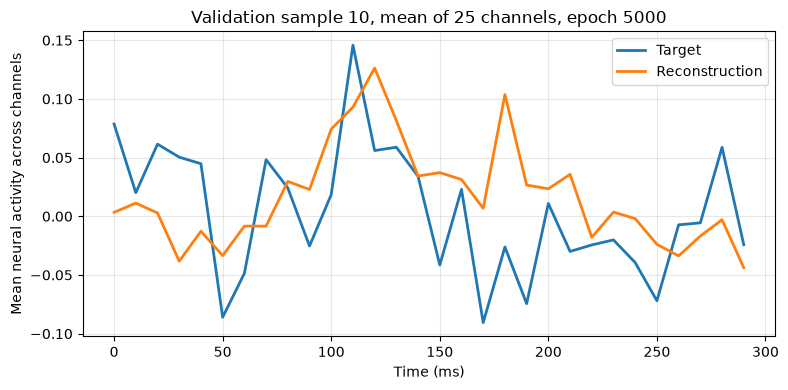

In [11]:
if not 0.0 < cfg.validation_fraction < 1.0:
    raise ValueError("validation_fraction must be between zero and one.")
# end if validation fraction is invalid

# Split unique images first, then assign all their repeated trials together.
full_dataset = loader.dataset
unique_image_indices = np.unique(full_dataset.image_indices)
n_validation_images = max(
    1,
    round(len(unique_image_indices) * cfg.validation_fraction),
)
if n_validation_images >= len(unique_image_indices):
    raise ValueError("The validation split leaves no training images.")
# end if training image split is empty

split_rng = np.random.default_rng(cfg.random_seed)
shuffled_image_indices = split_rng.permutation(unique_image_indices)
validation_image_indices = shuffled_image_indices[:n_validation_images]
is_validation_trial = np.isin(
    full_dataset.image_indices,
    validation_image_indices,
)
training_trial_indices = np.flatnonzero(~is_validation_trial).tolist()
validation_trial_indices = np.flatnonzero(is_validation_trial).tolist()
training_dataset = Subset(full_dataset, training_trial_indices)
validation_dataset = Subset(full_dataset, validation_trial_indices)

# Confirm that repeated presentations never cross the split boundary.
training_image_indices = set(
    full_dataset.image_indices[training_trial_indices].tolist()
)
validation_image_indices = set(
    full_dataset.image_indices[validation_trial_indices].tolist()
)
if training_image_indices & validation_image_indices:
    raise RuntimeError("An image appears in both training and validation.")
# end if repeated images leaked across splits
print(
    f"split: {len(training_image_indices)} images / "
    f"{len(training_trial_indices)} trials for training; "
    f"{len(validation_image_indices)} images / "
    f"{len(validation_trial_indices)} trials for validation"
)
pin_memory = torch.device(m.device).type == "cuda"
training_generator = torch.Generator()
training_generator.manual_seed(cfg.random_seed)
training_loader = DataLoader(
    training_dataset,
    batch_size=cfg.batch_size,
    shuffle=True,
    pin_memory=pin_memory,
    generator=training_generator,
)
validation_loader = DataLoader(
    validation_dataset,
    batch_size=cfg.batch_size,
    shuffle=False,
    pin_memory=pin_memory,
)

# Configure regression optimization over trainable parameters only.
optimizer = torch.optim.AdamW(
    m.get_trainable_parameters(),
    lr=cfg.learning_rate,
    weight_decay=cfg.weight_decay,
)
cost_function = neural_activity_timebin_mse_loss
use_precomputed_features = full_dataset.input_mode == "activations"
optimizer.zero_grad(set_to_none=True)

# Fit plain ridge on the same image-grouped split used by the neural model.
ridge_training_features, ridge_training_targets = (
    collect_concatenated_layer_regression_data(
        m,
        training_loader,
        use_precomputed_features,
        device=m.device,
    )
)
ridge_validation_features, ridge_validation_targets = (
    collect_concatenated_layer_regression_data(
        m,
        validation_loader,
        use_precomputed_features,
        device=m.device,
    )
)
ridge_encoding = linear_encoding(
    regression_type="ridge",
    cv_type="same",
)
ridge_encoding.fit(
    ridge_training_features,
    ridge_training_targets,
    transpose=False,
)
ridge_validation_predictions = ridge_encoding.predict(
    ridge_validation_features,
    transpose=False,
    transpose_output=False,
)
ridge_validation_mse = float(
    np.mean(
        (ridge_validation_predictions - ridge_validation_targets) ** 2
    )
)
print(
    f"concatenated-layer ridge | validation {ridge_validation_mse:.6f}"
)

# Evaluate the randomly initialized trainable model before any update.
initial_validation_loss = test_step(
    m,
    validation_loader,
    cost_function,
    use_precomputed_features,
    device=m.device,
)
print(f"epoch 000/{cfg.epochs:03d} | validation {initial_validation_loss:.6f}")
if cfg.reconstruction_plot_interval <= 0:
    raise ValueError("reconstruction_plot_interval must be positive.")
# end if reconstruction plot interval is invalid
plot_mean_channel_reconstruction(
    m,
    validation_dataset,
    cfg.reconstruction_sample_index,
    epoch=0,
    use_precomputed_features=use_precomputed_features,
    time_start_ms=cfg.time_start_ms,
    sampling_frequency=cfg.new_fs,
    device=m.device,
)

# Run one validation pass after every complete training epoch.
training_losses = []
validation_losses = []
for epoch in range(1, cfg.epochs + 1):
    training_loss = training_step(
        m,
        training_loader,
        optimizer,
        cost_function,
        use_precomputed_features,
        device=m.device,
    )
    validation_loss = test_step(
        m,
        validation_loader,
        cost_function,
        use_precomputed_features,
        device=m.device,
    )
    training_losses.append(training_loss)
    validation_losses.append(validation_loss)
    print(
        f"epoch {epoch:03d}/{cfg.epochs:03d} | "
        f"train {training_loss:.6f} | validation {validation_loss:.6f}"
    )

    # Show progress periodically and always include the final model.
    should_plot_reconstruction = (
        epoch % cfg.reconstruction_plot_interval == 0
        or epoch == cfg.epochs
    )
    if should_plot_reconstruction:
        plot_mean_channel_reconstruction(
            m,
            validation_dataset,
            cfg.reconstruction_sample_index,
            epoch=epoch,
            use_precomputed_features=use_precomputed_features,
            time_start_ms=cfg.time_start_ms,
            sampling_frequency=cfg.new_fs,
            device=m.device,
        )
    # end if reconstruction should be plotted
# end for epoch


torch.Size([64, 30, 25])


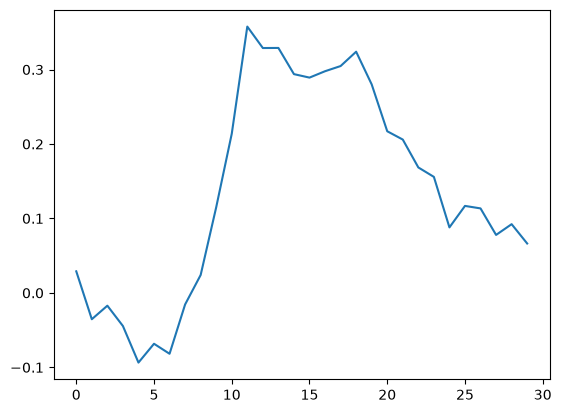

In [12]:
for i in training_loader:
    print(i[1].shape)
    y = i[1][:, :, 1].mean(dim=0)
    plt.plot(y.detach().cpu().numpy())
    break

## Training curves, ridge reference, and temporal layer attention

The black star is the validation MSE of fixed-alpha ridge regression using the selected DINO layer vectors concatenated into one feature vector. Its final-epoch x-position is only for display; ridge is fitted once on the same image-grouped training split.

feature attention | best validation 0.044535 at epoch 169


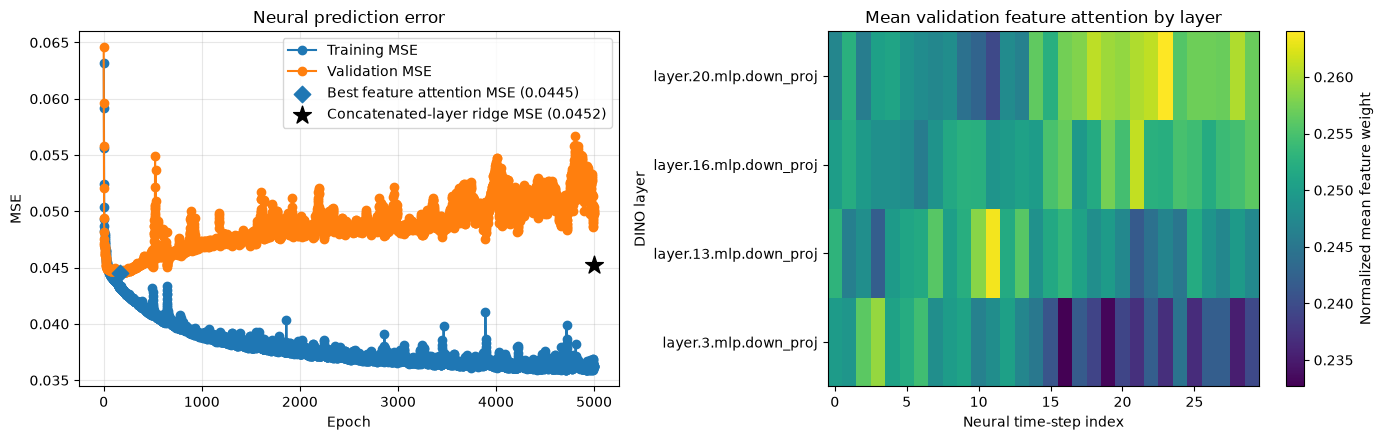

In [13]:
# Average attention over all validation stimuli after training.
m.eval()
validation_attention = []
with torch.no_grad():
    for inputs, _ in validation_loader:
        inputs = inputs.to(m.device)
        _, attention_weights = m(
            inputs,
            use_precomputed_features=use_precomputed_features,
        )
        layer_attention = aggregate_attention_by_layer(
            attention_weights
        )
        validation_attention.append(layer_attention.cpu())
    # end for validation batch
# end with no gradient tracking

mean_layer_attention = torch.cat(validation_attention, dim=0).mean(dim=0)

# Attention is constant inside each fine-time block produced by one coarse query.
mean_fine_attention = mean_layer_attention.repeat_interleave(
    m.get_temporal_compression_ratio(),
    dim=0,
)

# Plot optimization error and the final validation-set attention schedule.
training_epochs = np.arange(1, len(training_losses) + 1)
validation_epochs = np.arange(0, len(validation_losses) + 1)
all_validation_losses = np.asarray(
    [initial_validation_loss, *validation_losses]
)
best_validation_index = int(np.argmin(all_validation_losses))
best_validation_epoch = int(validation_epochs[best_validation_index])
best_validation_loss = float(
    all_validation_losses[best_validation_index]
)
print(
    f"{cfg.attention_granularity} attention | best validation "
    f"{best_validation_loss:.6f} at epoch {best_validation_epoch:03d}"
)

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
axes[0].plot(
    training_epochs,
    training_losses,
    marker="o",
    label="Training MSE",
)
axes[0].plot(
    validation_epochs,
    all_validation_losses,
    marker="o",
    label="Validation MSE",
)
axes[0].scatter(
    best_validation_epoch,
    best_validation_loss,
    marker="D",
    s=70,
    zorder=4,
    label=(
        f"Best {cfg.attention_granularity} attention MSE "
        f"({best_validation_loss:.4f})"
    ),
)
axes[0].scatter(
    validation_epochs[-1],
    ridge_validation_mse,
    marker="*",
    s=180,
    color="black",
    zorder=4,
    label=f"Concatenated-layer ridge MSE ({ridge_validation_mse:.4f})",
)
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("MSE")
axes[0].set_title("Neural prediction error")
axes[0].grid(alpha=0.3)
axes[0].legend()

attention_image = axes[1].imshow(
    mean_fine_attention.T.numpy(),
    aspect="auto",
    origin="lower",
    interpolation="nearest",
    cmap="viridis",
)
axes[1].set_xlabel("Neural time-step index")
axes[1].set_ylabel("DINO layer")
axes[1].set_title(
    f"Mean validation {cfg.attention_granularity} attention by layer"
)
axes[1].set_yticks(np.arange(len(m.get_layer_names())))
axes[1].set_yticklabels(m.get_layer_names())
attention_label = (
    "Layer attention weight"
    if cfg.attention_granularity == "layer"
    else "Normalized mean feature weight"
)
fig.colorbar(attention_image, ax=axes[1], label=attention_label)
fig.tight_layout()
plt.show()
